###  Virtual environment setup

In [1]:
#Create new virtual environment to download stock data on spark session

import sys
print(sys.executable)

/home/hduser/pyspark_venv/bin/python


### Hadoop and Spark Session Initialization and Configuration in virtual environment

In [2]:
import os
import sys
import findspark

# Hadoop & Spark configuration
os.environ["SPARK_HOME"] = "/usr/local/spark"
os.environ["PYSPARK_PYTHON"] = "/home/hduser/pyspark_venv/bin/python3"

# Initialize findspark
findspark.init()

from pyspark.sql import SparkSession

SPARK_DRIVER_MEMORY = "16g"
SPARK_MAX_RESULT_SIZE = "8g"

# Start Spark session
try:
    SparkSession.builder.getOrCreate().stop()
except:
    pass

spark = (
    SparkSession.builder
    .appName("Hadoop_Spark_Pipeline")
    .config("spark.driver.memory", SPARK_DRIVER_MEMORY)
    .config("spark.driver.maxResultSize", SPARK_MAX_RESULT_SIZE)
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

print(f"PySpark Session launched in: {sys.executable}")
print(f"Spark Master: {spark.sparkContext.master}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/19 23:13:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


PySpark Session launched in: /home/hduser/pyspark_venv/bin/python
Spark Master: local[*]


Spark uses the local[*] to run the application locally and maximize parallel processing within the host machine by using as many workers as possible.

### Downloading raw data

In [3]:
import yfinance as yf
import pandas as pd
import time
from datetime import datetime

## ticker for Microsoft stock
TICKER_SYMBOL = "MSFT"

download_start_time = time.time()
ticker_data = yf.Ticker(TICKER_SYMBOL)

##this will download data from January 2020 to present

pandas_df = ticker_data.history(start="2020-01-01")
pandas_df = pandas_df.reset_index()
download_end_time = time.time()

print(f"Total observation: {len(pandas_df)}")

download_time = download_end_time - download_start_time
total_observations = len(pandas_df)

print(f"\nDownload time: {download_time:.4f} seconds")

# Convert to Spark DataFrame

conversion_start_time = time.time()
spark_df = spark.createDataFrame(pandas_df)
conversion_end_time = time.time()

conversion_time = conversion_end_time - conversion_start_time
data_size_mb = pandas_df.memory_usage(deep=True).sum() / (1024 * 1024)

print(f"Conversion to Spark DF Time: {conversion_time:.4f} seconds")
print(f"Data Size (Pandas in-memory): {data_size_mb:.4f} MB")

Total observation: 1457

Download time: 0.6809 seconds
Conversion to Spark DF Time: 5.2115 seconds
Data Size (Pandas in-memory): 0.0891 MB


### Cleaning up raw data

In [6]:
from pyspark.sql.functions import round, to_date, col

# Convert Date to proper format and round numeric columns
spark_df = spark_df.withColumn("Date", to_date("Date"))
for col_name in ['Open', 'High', 'Low', 'Close']:
    spark_df = spark_df.withColumn(col_name, round(col(col_name), 2))

row_count = spark_df.count()
spark_df.show(5, truncate=False)

+----------+------+------+------+------+--------+---------+------------+
|Date      |Open  |High  |Low   |Close |Volume  |Dividends|Stock Splits|
+----------+------+------+------+------+--------+---------+------------+
|2020-01-02|151.04|152.9 |150.61|152.79|22622100|0.0      |0.0         |
|2020-01-03|150.6 |152.15|150.36|150.89|21116200|0.0      |0.0         |
|2020-01-06|149.42|151.35|148.88|151.28|20813700|0.0      |0.0         |
|2020-01-07|151.55|151.89|149.65|149.9 |21634100|0.0      |0.0         |
|2020-01-08|151.18|152.96|150.25|152.29|27746500|0.0      |0.0         |
+----------+------+------+------+------+--------+---------+------------+
only showing top 5 rows



Before data written to HDFS, initial data transformation is made to avoid errors and maximize computing storage capacity. 

Date column is converted to date format to remove time component. Without transformation, when we read the data back from HDFS, Spark's inferSchema may read Date column a timestamp or string. It will need extra processing to treat it as a calendar date for filtering or grouping. It will become harder to aggregate data. 

It is also important to round the data to two decimal place. Although storing full value will provide more precision, the downside of this can take more storage space on HDFS. 

### Data Storage on HDFS 

In [7]:
directory = "hdfs://localhost:9000/user/hduser/stock_data_output"

(
    spark_df
    .coalesce(1)  # One CSV file
    .write
    .mode("overwrite")
    .option("header", "true")
    .csv(directory)
)

print(f"Data successfully written to HDFS at: {directory}")

Data successfully written to HDFS at: hdfs://localhost:9000/user/hduser/stock_data_output


### Reading data back from HDFS on Pyspark engine

In [44]:
spark_df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(directory)

print("\n Data loaded back from HDFS:")
spark_df.printSchema()
spark_df.show(5)


 Data loaded back from HDFS:
root
 |-- Date: date (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: integer (nullable = true)
 |-- Dividends: double (nullable = true)
 |-- Stock Splits: double (nullable = true)

+----------+------+------+------+------+--------+---------+------------+
|      Date|  Open|  High|   Low| Close|  Volume|Dividends|Stock Splits|
+----------+------+------+------+------+--------+---------+------------+
|2020-01-02|151.04| 152.9|150.61|152.79|22622100|      0.0|         0.0|
|2020-01-03| 150.6|152.15|150.36|150.89|21116200|      0.0|         0.0|
|2020-01-06|149.42|151.35|148.88|151.28|20813700|      0.0|         0.0|
|2020-01-07|151.55|151.89|149.65| 149.9|21634100|      0.0|         0.0|
|2020-01-08|151.18|152.96|150.25|152.29|27746500|      0.0|         0.0|
+----------+------+------+------+------+--------+---------+------------+
only 

In [45]:
print(type(spark_df))

<class 'pyspark.sql.dataframe.DataFrame'>


### Data storage: CSV file storage on local

For reference only

In [46]:
# Define the output directory
OUTPUT_DIR = "file:///home/hduser/stock_data_output"
OUTPUT_FILENAME = "MFS_stock.csv"

# 1. Repartition to one CSV
(
    spark_df
    .coalesce(1) 
    .write
    .mode("overwrite") # Overwrite the directory if it already exists
    .option("header", "true") # Include the column names as the first row
    .csv(OUTPUT_DIR)
)

# 2. Get the part-file name (Spark writes a random name)
import os
import glob

# writes to the local file system (file://) and Find the part file and its directory
part_file_path = glob.glob(os.path.join("/home/hduser/stock_data_output", "part-*.csv"))[0]
final_path = os.path.join("/home/hduser/", OUTPUT_FILENAME)

# Rename the file to the desired, clean name
os.rename(part_file_path, final_path)

# Clean up the unnecessary output directory and metadata files
import shutil
shutil.rmtree("/home/hduser/stock_data_output")

print(f"\n Data successfully saved as a single CSV file to: {final_path}")


 Data successfully saved as a single CSV file to: /home/hduser/MFS_stock.csv


### Load CSV File into Spark DataFrame

In [12]:
# Initialize a Spark session
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MakeitExecutable") \
    .getOrCreate()

# Define the path to your CSV file (use a local or relative path)
csv_file_path = "hdfs://localhost:9000/MFS_stock.csv"

# Load the CSV file into a Spark DataFrame
spark_df = spark.read.csv(csv_file_path, header=True, inferSchema=True)

# Show the first few rows of the DataFrame
spark_df.show(5)

+----------+------+------+------+------+--------+---------+------------+
|      Date|  Open|  High|   Low| Close|  Volume|Dividends|Stock Splits|
+----------+------+------+------+------+--------+---------+------------+
|2020-01-02|151.04| 152.9|150.61|152.79|22622100|      0.0|         0.0|
|2020-01-03| 150.6|152.15|150.36|150.89|21116200|      0.0|         0.0|
|2020-01-06|149.42|151.35|148.88|151.28|20813700|      0.0|         0.0|
|2020-01-07|151.55|151.89|149.65| 149.9|21634100|      0.0|         0.0|
|2020-01-08|151.18|152.96|150.25|152.29|27746500|      0.0|         0.0|
+----------+------+------+------+------+--------+---------+------------+
only showing top 5 rows



### Understanding the data


Filtering numeric columns from the dataset to check null values

In [13]:
# Import necessary types for comparison
from pyspark.sql.types import DoubleType, IntegerType, FloatType, LongType, ShortType, DecimalType

def get_numeric_cols(df):
    numeric_types = (DoubleType, IntegerType, FloatType, LongType, ShortType, DecimalType)
    
    # Iterate through the schema (list of (column_name, data_type_string))
    numeric_cols = [
        field.name 
        for field in df.schema 
        if isinstance(field.dataType, numeric_types)
    ]
    return numeric_cols

# Get the list of numeric columns from your DataFrame
numeric_columns = get_numeric_cols(spark_df)

print(f"All Columns: {spark_df.columns}")
print(f"Numeric Columns: {numeric_columns}")

All Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']
Numeric Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']


In [14]:
from pyspark.sql.functions import col, sum as spark_sum, when

def check_numeric_nulls(df, numeric_cols):
    """Calculates the null count for only the numeric columns."""
    
      
    # Create aggregation expressions only for the numeric columns
    agg_exprs = [
        spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
        for c in numeric_cols
    ]

    # Perform the aggregation
    numeric_null_summary_df = df.agg(*agg_exprs)

    return numeric_null_summary_df

numeric_nulls_df = check_numeric_nulls(spark_df, numeric_columns)

print("Null values")
numeric_nulls_df.show()

Null values
+----+----+---+-----+------+---------+------------+
|Open|High|Low|Close|Volume|Dividends|Stock Splits|
+----+----+---+-----+------+---------+------------+
|   0|   0|  0|    0|     0|        0|           0|
+----+----+---+-----+------+---------+------------+



In [15]:
numeric_stats_df = spark_df.select(*numeric_columns).describe()

descriptive_stats_pandas_df = numeric_stats_df.toPandas()

print("\n--- Descriptive Statistics for Numeric Columns (Pandas Format) ---")
descriptive_stats_pandas_df

25/10/19 21:38:56 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.



--- Descriptive Statistics for Numeric Columns (Pandas Format) ---


,summary,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,count,1457,1457,1457,1457,1457,1457,1457
1,mean,310.3222580645164,313.31781056966344,307.23109814687683,310.4123404255317,2.7691724332875773E7,0.010494166094715167,0.0
2,stddev,97.23790109232081,97.54053090893586,96.74256903286658,97.16545253761805,1.2441658960632134E7,0.08397345620156811,0.0
3,min,130.69,134.08,126.41,129.17,6664953,0.0,0.0
4,max,554.32,554.54,531.03,534.76,97012700,0.83,0.0


### Evalutation on Big Data using 5V:

    Big data is evaluated using 5V: 
    
    -Volume: check data size and shape.

    -Velocity: measure processing speed.

    -Variety: analyze data types and formats.

    -Veracity: check data quality and reliability.

    -Value: assess usefulness and relevance to our goals.

### Velocity comparision between Spark and Pandas

In [16]:
# Performance comparision

import yfinance as yf
import pandas as pd
import time
from datetime import datetime

## ticker for Microsoft stock
TICKER_SYMBOL = "MSFT"

download_start_time = time.time()
ticker_data = yf.Ticker(TICKER_SYMBOL)

##this will download data from January 2020 to present

pandas_df = ticker_data.history(start="2020-01-01")
pandas_df = pandas_df.reset_index()
download_end_time = time.time()

print(f"Total observation: {len(pandas_df)}")

download_time = download_end_time - download_start_time
total_observations = len(pandas_df)

print(f"\nDownload time: {download_time:.4f} seconds")

# Convert to Spark DataFrame

conversion_start_time = time.time()
spark_df = spark.createDataFrame(pandas_df)
conversion_end_time = time.time()

conversion_time = conversion_end_time - conversion_start_time
data_size_mb = pandas_df.memory_usage(deep=True).sum() / (1024 * 1024)

print(f"Conversion to Spark DF Time: {conversion_time:.4f} seconds")
print(f"Data Size (Pandas in-memory): {data_size_mb:.4f} MB")

Total observation: 1457

Download time: 0.4329 seconds
Conversion to Spark DF Time: 0.0264 seconds
Data Size (Pandas in-memory): 0.0891 MB


In [17]:
import yfinance as yf
import pandas as pd
import time
from datetime import datetime
from pyspark.sql import SparkSession
# Note: We are now using LongType and assuming the 6-field schema fix from before
from pyspark.sql.types import StructType, StructField, DateType, DoubleType, LongType 

# --- Configuration ---
TICKER = 'MSFT'
START_DATE = '2020-01-01'
# OUTPUT_DIR is no longer needed, as we are not saving the data

# --- Schema Definition for Spark DataFrame (MATCHING 6 COLUMNS) ---
# Date, Open, High, Low, Close, Volume
schema = StructType([
    StructField("Date", DateType(), False),
    StructField("Open", DoubleType(), True),
    StructField("High", DoubleType(), True),
    StructField("Low", DoubleType(), True),
    StructField("Close", DoubleType(), True),
    StructField("Volume", LongType(), True) 
])

# --- Spark Session Initialization ---
def create_spark_session():
    return SparkSession.builder \
        .appName(f"PySparkSingleTickerVelocity_{TICKER}") \
        .master("local[1]") \
        .getOrCreate()


def run_pyspark_workflow():
    print("Initializing Spark session...")
    spark_init_start = time.time()
    spark = create_spark_session()
    spark_init_time = time.time() - spark_init_start
    print(f"Spark Session Initialized (Master: {spark.conf.get('spark.master')})")

    total_start_time = time.time() 

    download_start = time.time()
    print(f"Starting yfinance download for {TICKER}...")
    try:
        pandas_df = yf.download(TICKER, start=START_DATE, progress=False).reset_index()
    except Exception as e:
        print(f"Error downloading {TICKER}: {e}")
        spark.stop()
        return

    download_time = time.time() - download_start

    if pandas_df.empty:
        print(f"No data found for: {TICKER}")
        spark.stop()
        return

    conversion_start = time.time()
    spark_df = spark.createDataFrame(pandas_df, schema=schema)
    conversion_time = time.time() - conversion_start

    
    action_start = time.time()
    
    # velocity component
    row_count = spark_df.count()
    spark_df.show(5) # Display the first 5 rows to ensure execution

    action_time = time.time() - action_start

    total_time = time.time() - total_start_time

    # --- Velocity Component Evaluation ---
    print("\n" + "="*50)
    print("PySpark Workflow Velocity Component Evaluation")
    print("="*50)

    print(f"Total observations: {row_count}\n")
    print(f"A. Spark Initialization Overhead: {spark_init_time:.4f} seconds")
    print(f"B. Download (yfinance/Pandas): {download_time:.4f} seconds")
    print(f"C. Conversion (Pandas to Spark DF): {conversion_time:.4f} seconds")
    print(f"D. Action/Processing (Spark Count & Show): {action_time:.4f} seconds")


if __name__ == '__main__':
    # No need to clean up OUTPUT_DIR since we are not writing to disk.
    run_pyspark_workflow()

Initializing Spark session...
Spark Session Initialized (Master: local[1])
Starting yfinance download for MSFT...


25/10/19 21:38:59 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
/tmp/ipykernel_4853/3168286510.py:45: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pandas_df = yf.download(TICKER, start=START_DATE, progress=False).reset_index()


+----------+------------------+------------------+------------------+------------------+--------+
|      Date|              Open|              High|               Low|             Close|  Volume|
+----------+------------------+------------------+------------------+------------------+--------+
|2020-01-02| 152.7911376953125|152.89577671233235|150.61276208742146|151.04082551521063|22622100|
|2020-01-03|150.88858032226562|152.15375554790847|150.35587801990002| 150.6032144567477|21116200|
|2020-01-06| 151.2786407470703|151.34523581046366| 148.8814652208115| 149.4236895425469|20813700|
|2020-01-07|149.89932250976562|151.88744937521383|149.65200051472752|151.55451759516868|21634100|
|2020-01-08|152.28697204589844|152.96237197756489|150.25127940622974|151.18350868587726|27746500|
+----------+------------------+------------------+------------------+------------------+--------+
only showing top 5 rows


PySpark Workflow Velocity Component Evaluation
Total observations: 1457

A. Spark Initializa

## Findings from the result:

     The comparative analysis evaluated the velocity component (speed) of data ingestion when using single-threaded Pandas versus a distributed PySpark environment. Due to the time required to initialize the Spark session and JVM, the spark takes longer to , Consequently, the PySpark workflow consistently exhibits a longer total execution time than the straightforward Pandas approach. 



## Volume 

In [18]:

import os
import pandas as pd

file_path = 'MFS_stock.csv'
file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
print(f"File size: {file_size_mb:.2f} MB")

df = pd.read_csv(file_path)
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

File size: 0.08 MB
Number of rows: 1457
Number of columns: 8


## Variety

In [19]:
print(df.dtypes.value_counts())
print(df.dtypes)

float64    6
object     1
int64      1
Name: count, dtype: int64
Date             object
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object


    The data consists of eight columns. It is composed of three numerical (prices and volume) and categorical/temporal (object). PySpark schema requires mapping temporal and numerical types correctly.

## Veracity 

In [20]:
missing = df.isnull().sum().sum()
duplicates = df.duplicated().sum()
print(f"Missing values: {missing}")
print(f"Duplicate rows: {duplicates}")

Missing values: 0
Duplicate rows: 0


## Value 

In [21]:
used_columns = ['Date', 'High', 'Low']
value_ratio = len(used_columns) / df.shape[1]
print(f"Value ratio (used columns / total): {value_ratio:.2f}")

Value ratio (used columns / total): 0.38


## Findings:
    Value ratio provides the answers for the percentage of data useful for our analytics goal. It is calculated by dividing the number of features used by the total features. The $62\%$ unused data is a strong justification for dimensionality reduction. Removing these non-essential variables is crucial as every unnecessary column adds to computational burden. 

# Advanced Data Analytics

### Data vaildation for time series analysis

    To conduct time series analysis, data should meet two requirements: 

    -Complete Temporal Coverage: The dataset must contain continuous records for the entire period of interest, with no gaps. Missing data points, especially missing one or more daily, can lead to inaccurate models that fail to identify important seasonal or cyclic behaviors.

    -Regular Intervals: Observations in the time series data must be consistently spaced at regular intervals.

    As we are analyzing stock market, we will deal with trading days. Non-trading days and public holidays will not be in records. We will avoid imputation values on those days because it can give misrepresentation of data.


### Time interval consistency validation

In [22]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import lag, datediff, col, sum, min, max, countDistinct, to_date, round
from pyspark.sql.window import Window
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType, FloatType
import yfinance as yf
import pandas as pd
import datetime


print("\n--- 3. Time Interval Validation ---")

# Ordering data by ascending order
window_spec = Window.orderBy("Date")

# Get the date of the previous trading day (lag by 1 row)
df_with_prev = spark_df.withColumn(
    "Previous_Date",
    lag(col("Date"), 1).over(window_spec)
)

# Calculate the difference in calendar days
df_with_diff = df_with_prev.withColumn(
    "Day_Difference",
    datediff(col("Date"), col("Previous_Date"))
)

# Filter out the first row 
df_diff_report = df_with_diff.filter(col("Previous_Date").isNotNull())

print("\n--- Sample of Consecutive Day Differences")
# Show the records with the most common difference [1] for daily 
#and the weekend difference [3] that is Friday, Saturday, Sunday and Monday
(
    df_diff_report
    .filter(col("Day_Difference").isin([1, 3]))
    .select("Previous_Date", "Date", "Day_Difference")
    .limit(6)
    .show()
)

# Aggregate to find the unique differences and report
validation_df = df_diff_report.agg(
    countDistinct("Day_Difference").alias("Num_Unique_Diffs"),
    min("Day_Difference").alias("Min_Day_Difference"),
    max("Day_Difference").alias("Max_Day_Difference"),
    F.collect_list(col("Day_Difference")).alias("All_Differences_List") # Collect all differences
)

# Show the results
validation_result = validation_df.collect()[0]

print("\n--- Consistency Validation Report ---")
print(f"Total Unique Intervals Found: {validation_result['Num_Unique_Diffs']}")
print(f"Minimum Gap (Days): {validation_result['Min_Day_Difference']}")
print(f"Maximum Gap (Days): {validation_result['Max_Day_Difference']}")
print(f"Common Gaps Found: {sorted(list(set(validation_result['All_Differences_List'])))[:7]}")

if validation_result['Min_Day_Difference'] == 1 and validation_result['Max_Day_Difference'] <= 7:
    print("\n Validation Passed")
else:
    print("\n Validation Failed")


--- 3. Time Interval Validation ---

--- Sample of Consecutive Day Differences


25/10/19 21:39:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/19 21:39:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/19 21:39:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/19 21:39:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/19 21:39:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+-------------------+-------------------+--------------+
|      Previous_Date|               Date|Day_Difference|
+-------------------+-------------------+--------------+
|2020-01-02 05:00:00|2020-01-03 05:00:00|             1|
|2020-01-03 05:00:00|2020-01-06 05:00:00|             3|
|2020-01-06 05:00:00|2020-01-07 05:00:00|             1|
|2020-01-07 05:00:00|2020-01-08 05:00:00|             1|
|2020-01-08 05:00:00|2020-01-09 05:00:00|             1|
|2020-01-09 05:00:00|2020-01-10 05:00:00|             1|
+-------------------+-------------------+--------------+



25/10/19 21:39:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/19 21:39:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/19 21:39:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/19 21:39:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.



--- Consistency Validation Report ---
Total Unique Intervals Found: 4
Minimum Gap (Days): 1
Maximum Gap (Days): 4
Common Gaps Found: [1, 2, 3, 4]

 Validation Passed


### Creating column for feature of interest

Target feature is calculated by averaging high and low price.

In [23]:
from pyspark.sql.functions import col
spark_df = spark_df.withColumn("Mid", (col("High") + col("Low")) / 2)

In [24]:
spark_df.show(5)

+-------------------+------------------+------------------+------------------+------------------+--------+---------+------------+------------------+
|               Date|              Open|              High|               Low|             Close|  Volume|Dividends|Stock Splits|               Mid|
+-------------------+------------------+------------------+------------------+------------------+--------+---------+------------+------------------+
|2020-01-02 05:00:00|151.04082551521063|152.89577671233235|150.61276208742146| 152.7911376953125|22622100|      0.0|         0.0| 151.7542693998769|
|2020-01-03 05:00:00| 150.6032144567477|152.15375554790847|150.35587801990002|150.88858032226562|21116200|      0.0|         0.0|151.25481678390423|
|2020-01-06 05:00:00| 149.4236895425469|151.34523581046366| 148.8814652208115| 151.2786407470703|20813700|      0.0|         0.0| 150.1133505156376|
|2020-01-07 05:00:00|151.55451759516868|151.88744937521383|149.65200051472752|149.89932250976562|21634100|

### Calculating max and min value of mid-point price

In [25]:
import pyspark.sql.functions as F

max_mid_value = spark_df.agg(F.max("Mid")).collect()[0][0]

max_mid_df = spark_df.filter(F.col("Mid") == max_mid_value).select("date", "Mid")

max_mid_df.show()

+-------------------+-----------------+
|               date|              Mid|
+-------------------+-----------------+
|2025-07-31 04:00:00|542.7827081438766|
+-------------------+-----------------+



In [26]:
import pyspark.sql.functions as F

min_mid_value = spark_df.agg(F.min("Mid")).collect()[0][0]

min_mid_df = spark_df.filter(F.col("Mid") == min_mid_value).select("date", "Mid")

# 3. Show the result
min_mid_df.show()

+-------------------+-----------------+
|               date|              Mid|
+-------------------+-----------------+
|2020-03-23 04:00:00|130.2443677149534|
+-------------------+-----------------+



### Convert Spark DataFrame to Pandas DataFrame

In [27]:
pandas_df = spark_df.toPandas()
pandas_df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Mid
0,2020-01-02 05:00:00,151.040826,152.895777,150.612762,152.791138,22622100,0.0,0.0,151.754269
1,2020-01-03 05:00:00,150.603214,152.153756,150.355878,150.888580,21116200,0.0,0.0,151.254817
2,2020-01-06 05:00:00,149.423690,151.345236,148.881465,151.278641,20813700,0.0,0.0,150.113351
3,2020-01-07 05:00:00,151.554518,151.887449,149.652001,149.899323,21634100,0.0,0.0,150.769725
4,2020-01-08 05:00:00,151.183509,152.962372,150.251279,152.286972,27746500,0.0,0.0,151.606826


In [28]:
print(f"From {pandas_df['Date'].min()} to {pandas_df['Date'].max()}")

From 2020-01-02 05:00:00 to 2025-10-17 04:00:00


In [29]:
print(pandas_df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'Mid'],
      dtype='object')


### Visualsing time series

### Annual trend

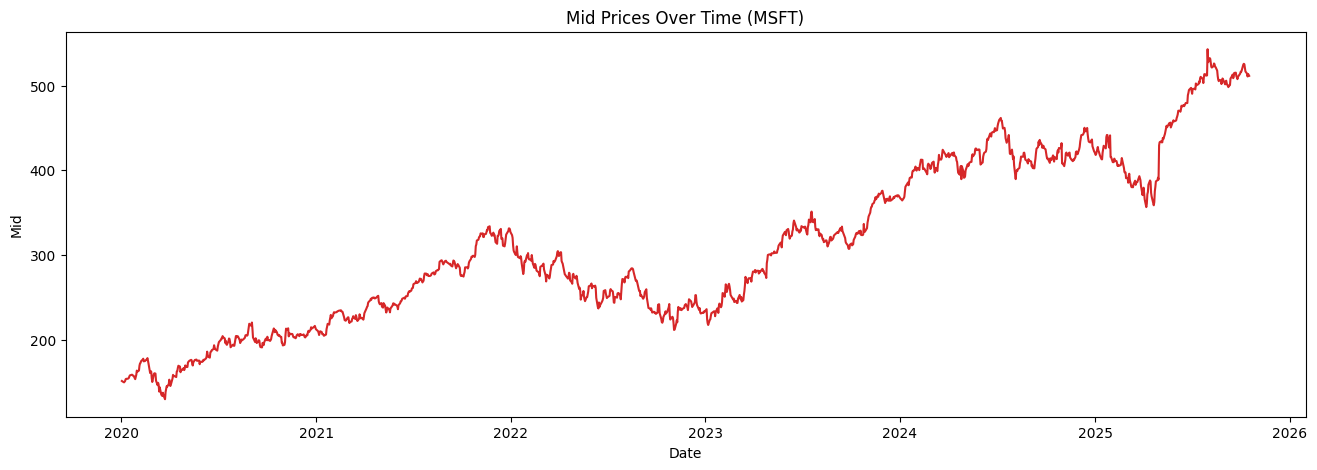

In [30]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import matplotlib as mpl

def plot_df(df, x, y, title="", xlabel='Date', ylabel='Mid', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(
    pandas_df, 
    x=pandas_df['Date'], 
    y=pandas_df['Mid'], 
    title='Mid Prices Over Time (MSFT)')

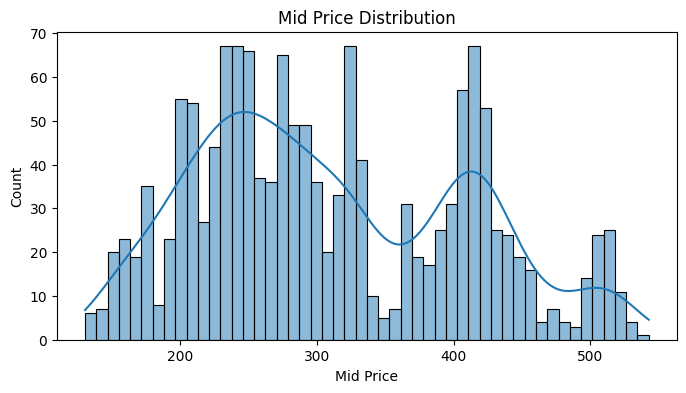

In [31]:
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(pandas_df["Mid"], bins=50, kde=True)
plt.title("Mid Price Distribution")
plt.xlabel("Mid Price")
plt.show()

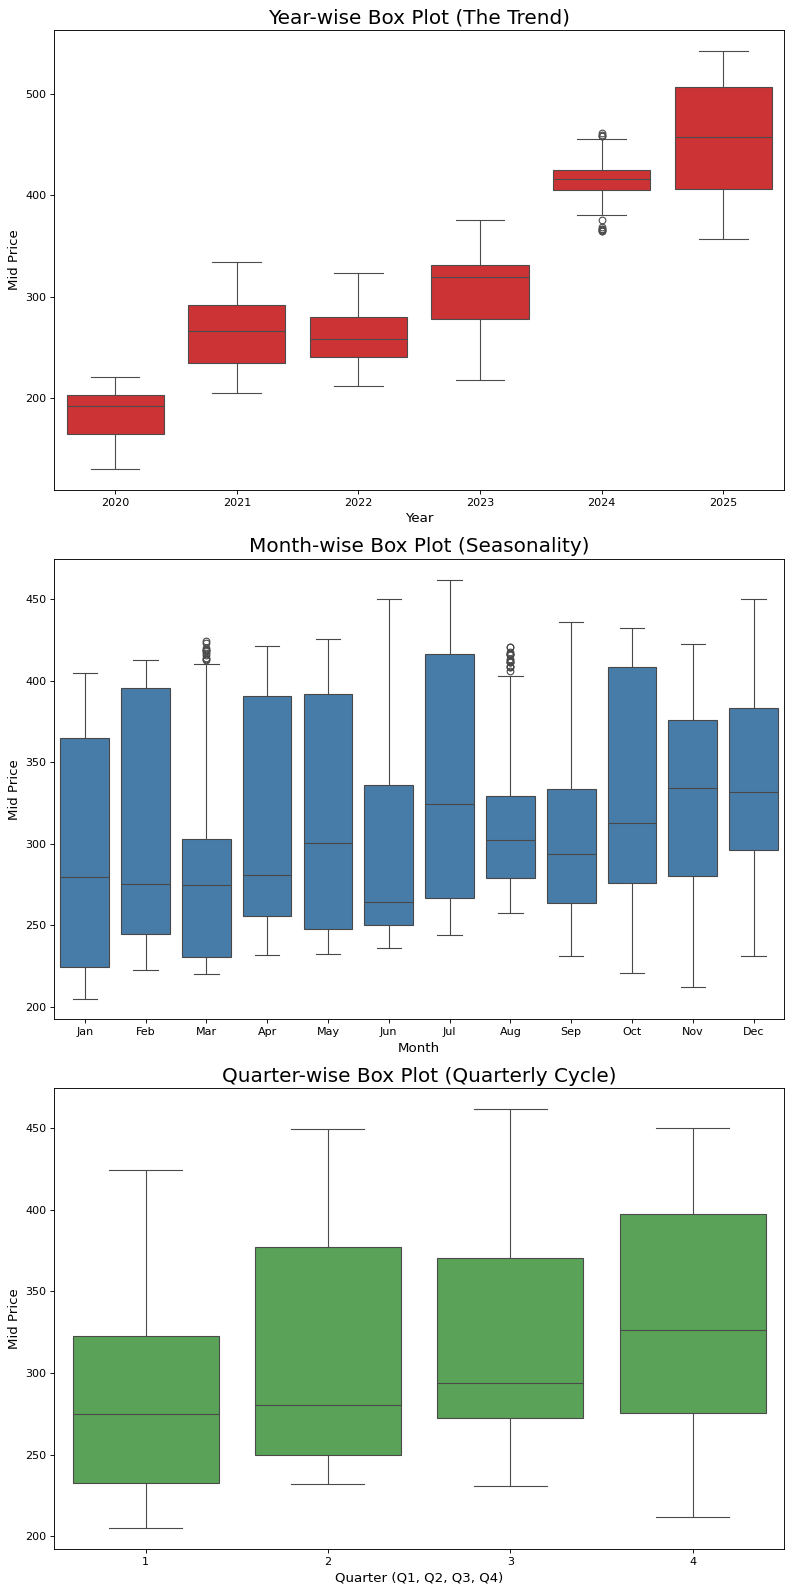

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pandas_df.copy()

df['Date'] = pd.to_datetime(df['Date'])
df['year'] = df['Date'].dt.year 
df['month'] = df['Date'].dt.strftime('%b')

df['quarter'] = df['Date'].dt.quarter.astype(str)
quarter_order = ['1', '2', '3', '4'] 
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

years_to_exclude = [df['year'].min(), df['year'].max()]
df_seasonal = df.loc[~df.year.isin(years_to_exclude), :].copy()

fig, axes = plt.subplots(3, 1, figsize=(10, 20), dpi=80) 

colors = sns.color_palette("Set1", 3)

sns.boxplot(x='year', y='Mid', data=df, ax=axes[0], color=colors[0]) 
axes[0].set_title('Year-wise Box Plot (The Trend)', fontsize=18)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Mid Price', fontsize=12)

sns.boxplot(
    x='month', 
    y='Mid', 
    data=df_seasonal,
    order=month_order, 
    ax=axes[1], color=colors[1]
)


axes[1].set_title('Month-wise Box Plot (Seasonality)', fontsize=18)
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_ylabel('Mid Price', fontsize=12)

sns.boxplot(
    x='quarter', 
    y='Mid', 
    data=df_seasonal,
    order=quarter_order,
    ax=axes[2], color=colors[2]
)
axes[2].set_title('Quarter-wise Box Plot (Quarterly Cycle)', fontsize=18)
axes[2].set_xlabel('Quarter (Q1, Q2, Q3, Q4)', fontsize=12)
axes[2].set_ylabel('Mid Price', fontsize=12)

plt.tight_layout()
plt.show()

### Insight: 

    Year-wise Box Plot (The Trend): 
        The market has experienced consistent growth in value over the years, with more variability in recent years (especially 2025). Between 2020-2022, prices were stable the value is below 300, but 2023-2025 saw steady price rises, with 2025 showing highest prices and wider spread, indicating increased volatility.
        
    Month-wise Box Plot (Seasonality):
        The average mid-price levels in January, February, July, October, and December are higher, while March to June show slightly lower medians and narrower ranges.Prices peak at the start and end of the year, easing mid-year.
        
    Quarter-wise Box Plot (Quarterly Cycle): 
        Price movements intensify in Q4, suggesting strong year-end effects. Q1 exhibits moderate medians in Q2 (April-Jun) and Q3 (Jul-Sep), with Q3 showing more spread and potential spikes.
    

### Seasonal Decomposition

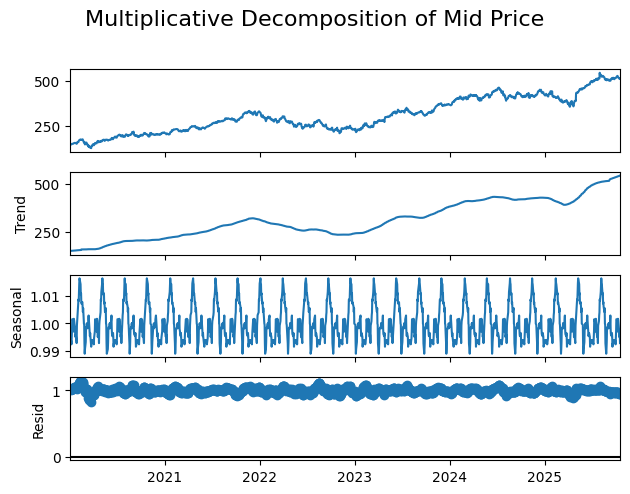

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm # statsmodels for the decomposition

df['Date'] = pd.to_datetime(pandas_df['Date'])

ts_series = pandas_df.set_index('Date')['Mid']

result = sm.tsa.seasonal_decompose(
    ts_series, 
    model='multiplicative',
    period=60, # Decomposing into a 60-day cycle (approx 2 trading months),
    extrapolate_trend='freq'
)

fig = result.plot()

fig.suptitle(f'Multiplicative Decomposition of Mid Price', fontsize=16, y=1.02)

for ax in fig.axes:
    ax.set_title("") 

plt.tight_layout()
plt.show()

### Insight: 

    Trend: The mid price's trend component reveals a steady upward movement from 2020 to 2025, indicating sustained asset value growth. A noticeable acceleration towards late 2024-2025 suggests stronger price momentum.
    
    Seasonal: The seasonal plot displays repeating  patterns with a narrow  range (around 0.99–1.01).This indicates that short-term seasonality in predictable market cycles, but not dominating price movement.
    
    Residual: Residual values fluctuate around 1 with no strong pattern. It indicates that consistent residual noise over time, and few extreme spikes, indicating a stable and predictable series, largely explained by trend and seasonality.


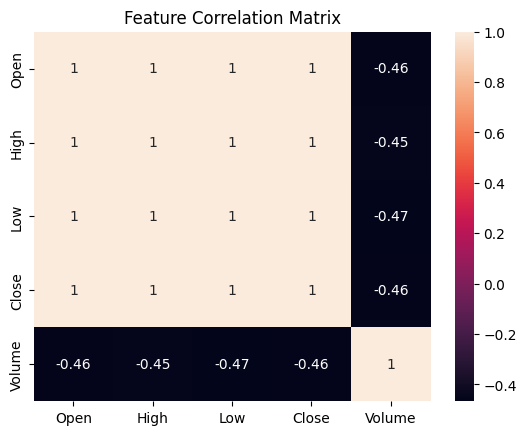

In [68]:
sns.heatmap(pandas_df[["Open", "High", "Low", "Close", "Volume"]].corr(), annot=True)
plt.title("Feature Correlation Matrix")
plt.show()

### Insights: 

    The correlation matrix reveals relationships among volume, close, low, high and opening prices. 


Price Features (Open, High, Low, Close):

    Open–High–Low–Close (1.00):
    There is a perfect positive correlation among all price-related features.
    This indicates that when one of these price points increases or decreases, the others follow in the exact same pattern.

Price vs Volume:

    -Volume vs Open (-0.46)

    -Volume vs High (-0.45)

    -Volume vs Low (-0.47)

    -Volume vs Close (-0.46)
    
There is a moderate negative correlation between trading volume and price levels. When prices are high, trading activity tends to decrease, and when prices drop, trading activity increases — possibly reflecting investor behavior like selling during dips or reduced activity during stable price periods.



## Stock market prediction on LSTM

In [69]:
pandas_df = spark_df.toPandas()
pandas_df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Mid
0,2020-01-02 05:00:00,151.040780,152.895731,150.612717,152.791092,22622100,0.0,0.0,151.754224
1,2020-01-03 05:00:00,150.603230,152.153771,150.355893,150.888596,21116200,0.0,0.0,151.254832
2,2020-01-06 05:00:00,149.423690,151.345236,148.881465,151.278641,20813700,0.0,0.0,150.113351
3,2020-01-07 05:00:00,151.554471,151.887403,149.651955,149.899277,21634100,0.0,0.0,150.769679
4,2020-01-08 05:00:00,151.183509,152.962372,150.251279,152.286972,27746500,0.0,0.0,151.606826


### Data preprocessing

In [78]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.regularizers import l2
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Look back window - Monthly trading cycles -21 days

In [79]:
df_model = pandas_df.set_index('Date')
data = df_model['Mid'].values
data = data.reshape(-1,1)


training_data_len = int(len(data) * 0.80)
train_data = data[:training_data_len]
test_data = data[training_data_len:]

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)


def create_dataset(dataset, time_step=1):
    X = []
    y = []
    for i in range(len(dataset) - time_step):
        a = dataset[i:(i + time_step), 0]  # input sequence
        X.append(a)
        y.append(dataset[i + time_step, 0])  
    return np.array(X), np.array(y)

time_step = 21
X_train, y_train = create_dataset(scaled_train,time_step)
X_test, y_test = create_dataset(scaled_test,time_step)

In [80]:
print(X_train.shape, y_train.shape)

(1144, 21) (1144,)


### Look back window - Monthly trading cycles -21 days

### Train-test split with 80% training and 20% test data

/home/hduser/pyspark_venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 21, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 21, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 172ms/step - loss: 0.0295 - val_loss: 0.0051
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - loss: 0.0046 - val_loss: 0.0024
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0042 - val_loss: 0.0024
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 0.0038 - val_loss: 0.0024
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 0.0035 - val_loss: 0.0023
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - loss: 0.0035 - val_loss: 0.0034
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0033 - val_loss: 0.0021
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 0.0032 - val_loss: 0.0021
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.0032 - val_loss: 0.0023
Epoch 10/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - loss: 0.0031 - val_loss: 0.0020
Epoch 11/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 12/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/ste

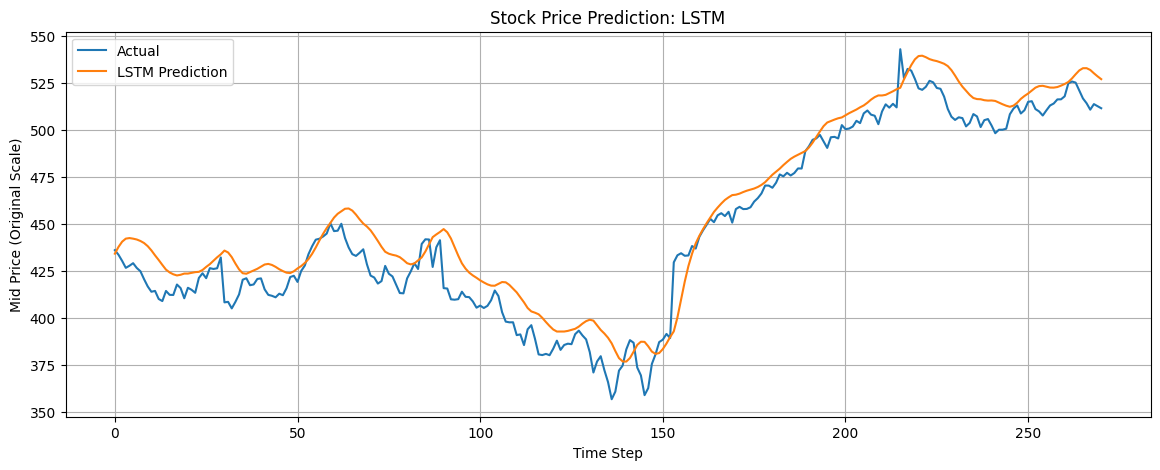

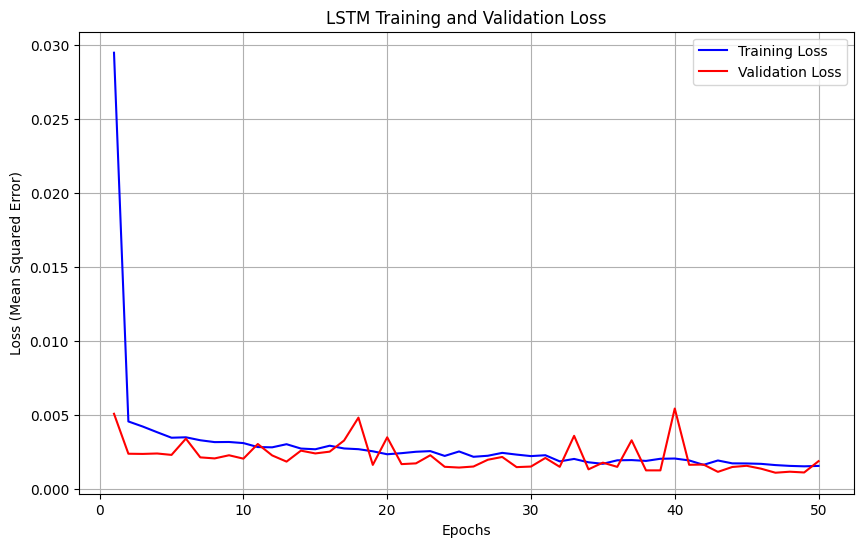

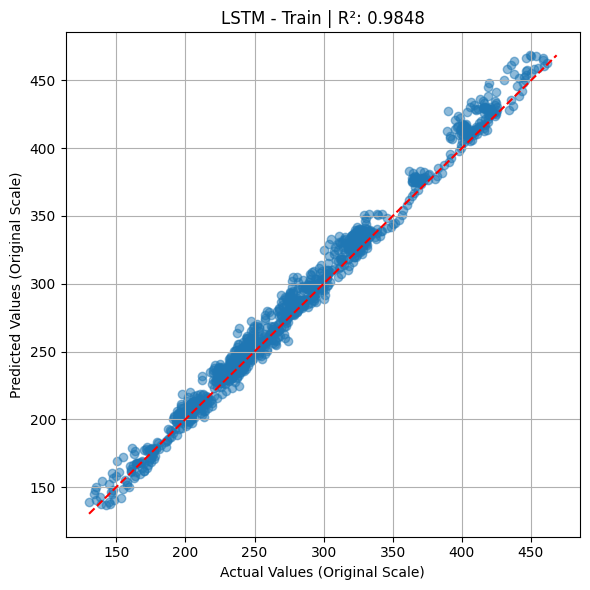

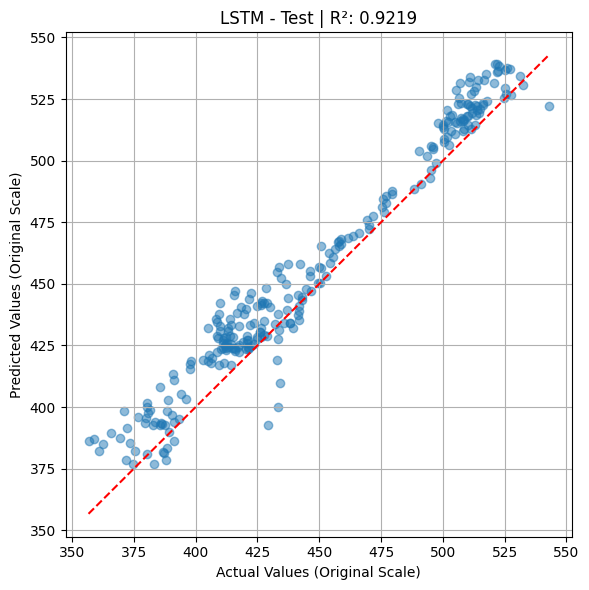

25/10/19 17:28:50 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 2411835 ms exceeds timeout 120000 ms
25/10/19 17:28:56 WARN SparkContext: Killing executors is not supported by current scheduler.
25/10/19 17:28:56 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$

25/10/19 17:28:56 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1240)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:296)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.java:23)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:1928)

25/10/19 17:28:56 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

25/10/19 17:28:57 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1240)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:296)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.java:23)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:1928)

25/10/19 17:28:57 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1240)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:296)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.java:23)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:1928)

...

25/10/19 17:28:57 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

25/10/19 17:28:58 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1240)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:296)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.java:23)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:1928)

25/10/19 17:28:58 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1240)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:296)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.java:23)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:1928)

25/10/19 17:28:58 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1240)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:296)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.java:23)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:1928)

Caused by: org.apache.spark.rpc.RpcEndpointNotFoundException: Cannot find endpoint: spark://CoarseGrainedScheduler@winly:37287
	at org.apache.spark.rpc.netty.NettyRpcEnv.$anonfun$asyncSetupEndpointRefByURI$1(NettyRpcEnv.scala:148)
	at org.apache.spark.rpc.netty.NettyRpcEnv.$anonfun$asyncSetupEndpointRefByURI$1$adapted(NettyRpcEnv.scala:144)
	at scala.concurrent.Future.$anonfun$flatMap$1(Future.scala:307)
	at scala.concurrent.impl.Promise.$anonfun$transformWith$1(Promise.scala:41)
	at scala.concurrent.impl.CallbackRunnable.run(Promise.scala:64)
	at org.apache.spark.util.ThreadUtils$$anon$1.execute(ThreadUtils.scala:99)
	at scala.concurrent.impl.ExecutionContextImpl$$anon$4.execute(ExecutionContextImpl.scala:138)
	at scala.concurrent.impl.CallbackRunnable.executeWithValue(Promise.scala:72)
	at scala.concurrent.impl.Promise$DefaultPromise.$anonfun$tryComplete$1(Promise.scala:288)
	at scala.concurrent.impl.Promise$DefaultPromise.$anonfun$tryComplete$1$adapted(Promise.scala:288)
	at scala.c

In [81]:
# Define the optimizer with a specific learning rate 
adam_optimizer = Adam(learning_rate=0.001)

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, kernel_regularizer=l2(0.00001), input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, kernel_regularizer=l2(0.00001), return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer=adam_optimizer, loss='mean_squared_error')
model.summary()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=50,      
    batch_size=32,   
    verbose=1
)

# Get predictions for training data


# Model Evaluation

# Predict on training and test sets
lstm_predictions_train = model.predict(X_train)
lstm_predictions_test = model.predict(X_test)

# Rescale predictions and targets
lstm_predictions_train = scaler.inverse_transform(lstm_predictions_train).flatten()
lstm_predictions_test = scaler.inverse_transform(lstm_predictions_test).flatten()

# Reshape and Inverse Transform Training Targets
Y_train_rescaled = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()

# Reshape and Inverse Transform Test Targets
Y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

print("\n")

# --- LSTM Scores ---
print("LSTM Performance")
print("Train MSE:", mean_squared_error(Y_train_rescaled, lstm_predictions_train))
print("Train MAE:", mean_absolute_error(Y_train_rescaled, lstm_predictions_train))
print("Train R² :", r2_score(Y_train_rescaled, lstm_predictions_train))

print("Test  MSE:", mean_squared_error(Y_test_rescaled, lstm_predictions_test))
print("Test  MAE:", mean_absolute_error(Y_test_rescaled, lstm_predictions_test))
print("Test  R² :", r2_score(Y_test_rescaled, lstm_predictions_test))


# --- 1. Visualizing Time Series Results (Actual vs. Prediction) ---
plt.figure(figsize=(14,5))
plt.plot(Y_test_rescaled, label='Actual')
plt.plot(lstm_predictions_test, label='LSTM Prediction')
plt.title('Stock Price Prediction: LSTM')
plt.xlabel('Time Step')
plt.ylabel('Mid Price (Original Scale)')
plt.legend()
plt.grid(True)
plt.show()


# --- 2. Plotting Loss ---
train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)') 
plt.legend()
plt.grid(True)
plt.show()


# --- 3. Plotting Actual vs. Predicted Scatter Plots ---

def plot_actual_vs_predicted(actual, predicted, model_name, dataset_type):
    r2 = r2_score(actual, predicted)
    plt.figure(figsize=(6, 6))
    plt.scatter(actual, predicted, alpha=0.5)
    
    # Use np.min/np.max for the ideal line to avoid PySpark conflicts
    min_val = np.min(np.concatenate([actual.flatten(), predicted.flatten()]))
    max_val = np.max(np.concatenate([actual.flatten(), predicted.flatten()]))
    
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Fit')  
    
    plt.xlabel('Actual Values (Original Scale)')
    plt.ylabel('Predicted Values (Original Scale)')
    plt.title(f'{model_name} - {dataset_type} | R²: {r2:.4f}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    
# --- LSTM Plots ---
plot_actual_vs_predicted(Y_train_rescaled, lstm_predictions_train, model_name='LSTM', dataset_type='Train')
plot_actual_vs_predicted(Y_test_rescaled, lstm_predictions_test, model_name='LSTM', dataset_type='Test')

### Different train-test split with 65% training and 35% test data

2025-10-19 14:10:20.724167: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
/home/hduser/pyspark_venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 21, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 21, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 160ms/step - loss: 0.0472 - val_loss: 0.0749
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - loss: 0.0078 - val_loss: 0.0371
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - loss: 0.0061 - val_loss: 0.0246
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0058 - val_loss: 0.0162
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - loss: 0.0061 - val_loss: 0.0141
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step - loss: 0.0054 - val_loss: 0.0109
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - loss: 0.0052 - val_loss: 0.0114
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - loss: 0.0051 - val_loss: 0.0268
Epoch 9/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - loss: 0.0047 - val_loss: 0.0161
Epoch 10/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step - loss: 0.0046 - val_loss: 0.0081
Epoch 11/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 150ms/step - loss: 0.0045 - val_loss: 0.0144
Epoch 12/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step 

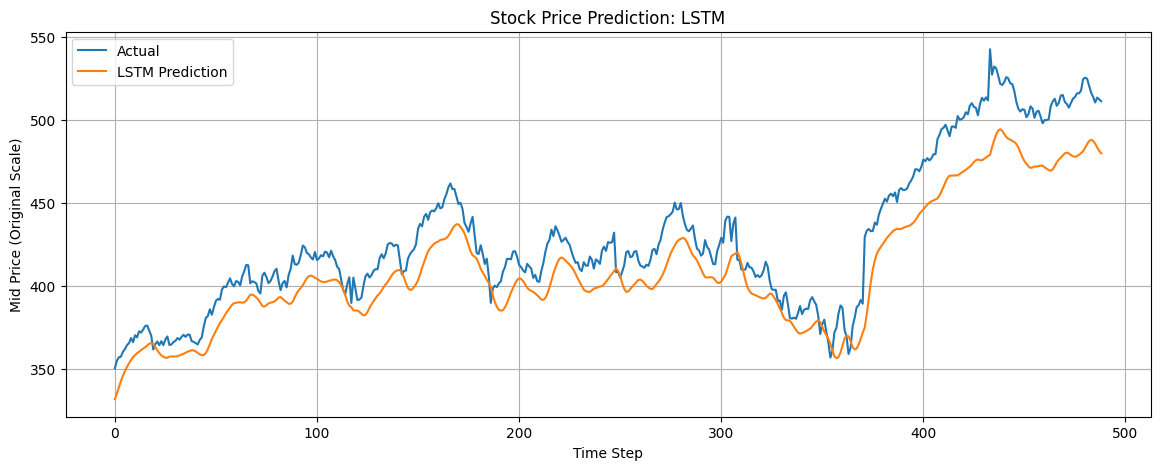

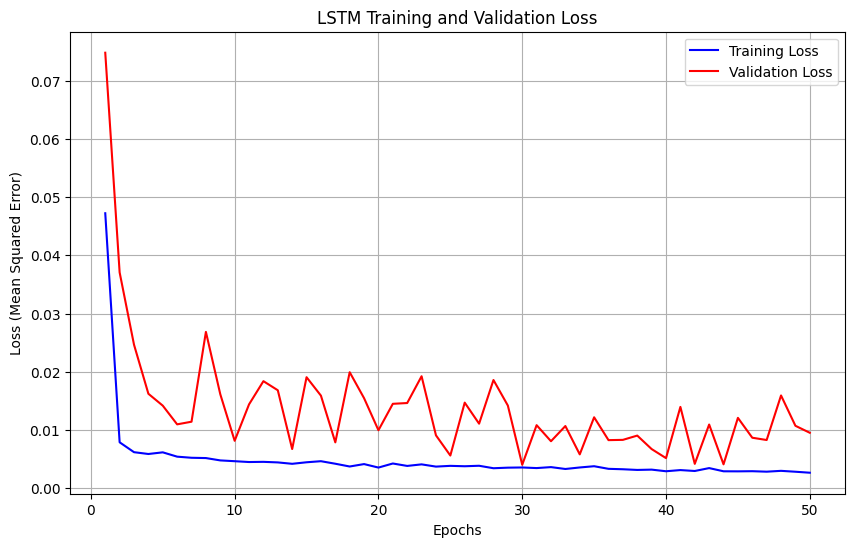

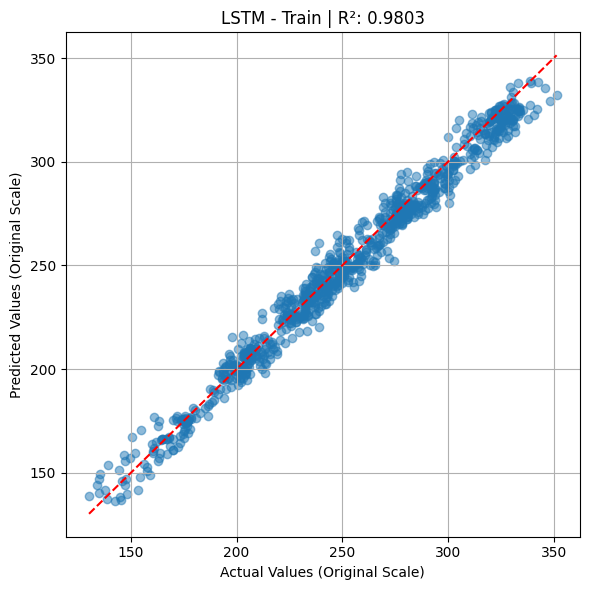

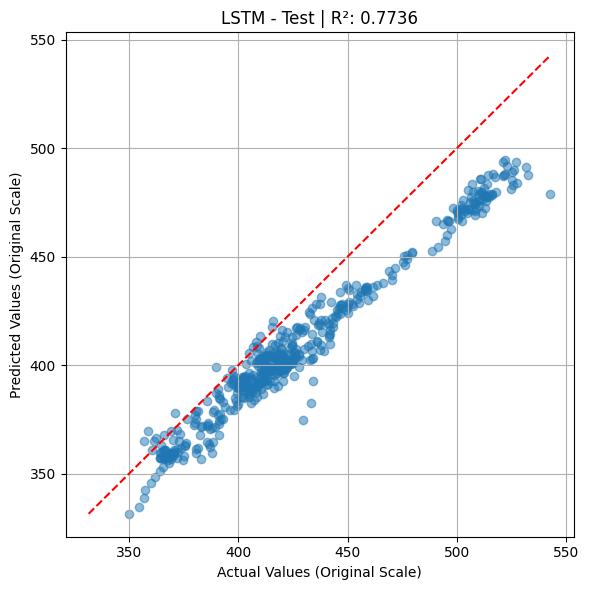

In [36]:
df_model = pandas_df.set_index('Date')
data = df_model['Mid'].values
data = data.reshape(-1,1)


training_data_len = int(len(data) * 0.65)
train_data = data[:training_data_len]
test_data = data[training_data_len:]

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)


def create_dataset(dataset, time_step=1):
    X = []
    y = []
    for i in range(len(dataset) - time_step):
        a = dataset[i:(i + time_step), 0]  # input sequence
        X.append(a)
        y.append(dataset[i + time_step, 0])  
    return np.array(X), np.array(y)

time_step = 21
X_train, y_train = create_dataset(scaled_train,time_step)
X_test, y_test = create_dataset(scaled_test,time_step)



# Define the optimizer with a specific learning rate 
adam_optimizer = Adam(learning_rate=0.001)

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, kernel_regularizer=l2(0.00001), input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, kernel_regularizer=l2(0.00001), return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer=adam_optimizer, loss='mean_squared_error')
model.summary()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=50,      
    batch_size=32,   
    verbose=1
)

# Get predictions for training data

print("\n")

# Model Evaluation

# Predict on training and test sets
lstm_predictions_train = model.predict(X_train)
lstm_predictions_test = model.predict(X_test)

# Rescale predictions and targets
lstm_predictions_train = scaler.inverse_transform(lstm_predictions_train).flatten()
lstm_predictions_test = scaler.inverse_transform(lstm_predictions_test).flatten()

# Reshape and Inverse Transform Training Targets
Y_train_rescaled = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()

# Reshape and Inverse Transform Test Targets
Y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()


# --- LSTM Scores ---
print(" LSTM Performance")
print("Train MSE:", mean_squared_error(Y_train_rescaled, lstm_predictions_train))
print("Train MAE:", mean_absolute_error(Y_train_rescaled, lstm_predictions_train))
print("Train R² :", r2_score(Y_train_rescaled, lstm_predictions_train))

print("Test  MSE:", mean_squared_error(Y_test_rescaled, lstm_predictions_test))
print("Test  MAE:", mean_absolute_error(Y_test_rescaled, lstm_predictions_test))
print("Test  R² :", r2_score(Y_test_rescaled, lstm_predictions_test))


# --- 1. Visualizing Time Series Results (Actual vs. Prediction) ---
plt.figure(figsize=(14,5))
plt.plot(Y_test_rescaled, label='Actual')
plt.plot(lstm_predictions_test, label='LSTM Prediction')
plt.title('Stock Price Prediction: LSTM')
plt.xlabel('Time Step')
plt.ylabel('Mid Price (Original Scale)')
plt.legend()
plt.grid(True)
plt.show()


# --- 2. Plotting Loss ---
train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)') 
plt.legend()
plt.grid(True)
plt.show()


# --- 3. Plotting Actual vs. Predicted Scatter Plots ---

def plot_actual_vs_predicted(actual, predicted, model_name, dataset_type):
    r2 = r2_score(actual, predicted)
    plt.figure(figsize=(6, 6))
    plt.scatter(actual, predicted, alpha=0.5)
    
    # Use np.min/np.max for the ideal line to avoid PySpark conflicts
    min_val = np.min(np.concatenate([actual.flatten(), predicted.flatten()]))
    max_val = np.max(np.concatenate([actual.flatten(), predicted.flatten()]))
    
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Fit')  
    
    plt.xlabel('Actual Values (Original Scale)')
    plt.ylabel('Predicted Values (Original Scale)')
    plt.title(f'{model_name} - {dataset_type} | R²: {r2:.4f}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    
# --- LSTM Plots ---
plot_actual_vs_predicted(Y_train_rescaled, lstm_predictions_train, model_name='LSTM', dataset_type='Train')
plot_actual_vs_predicted(Y_test_rescaled, lstm_predictions_test, model_name='LSTM', dataset_type='Test')

### Look back window - Quarterly trading cycles - 60 days

/home/hduser/pyspark_venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.0336 - val_loss: 0.0063
Epoch 2/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0045 - val_loss: 0.0019
Epoch 3/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0033 - val_loss: 0.0018
Epoch 4/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0035 - val_loss: 0.0030
Epoch 5/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0030 - val_loss: 0.0034
Epoch 6/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0029 - val_loss: 0.0020
Epoch 7/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0027 - val_loss: 0.0017
Epoch 8/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0029 - val_loss: 0.0019
Epoch 9/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0027 - val_loss: 0.0029
Epoch 10/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0025 - val_loss: 0.0016
Epoch 11/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0024 - val_loss: 0.0014
Epoch 12/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0

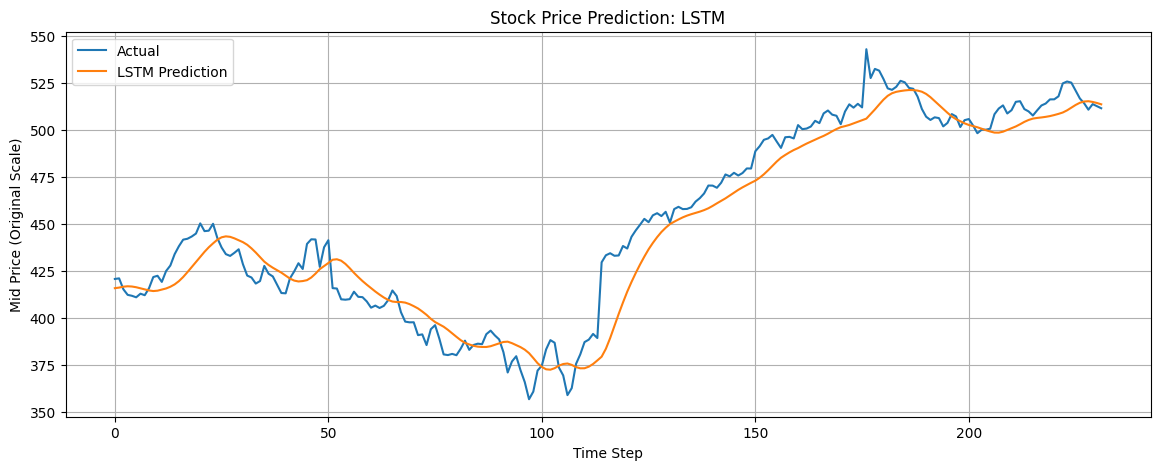

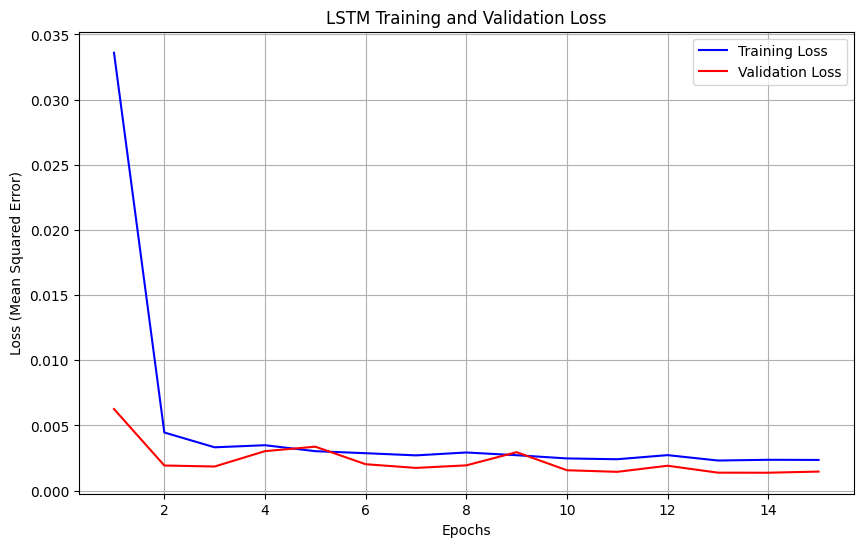

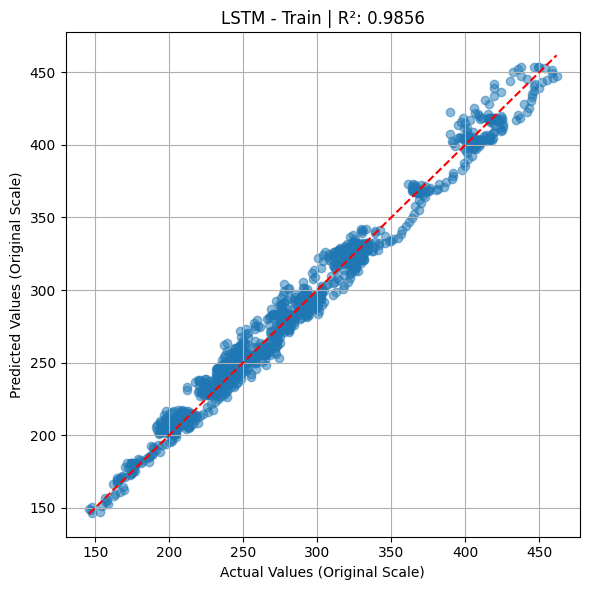

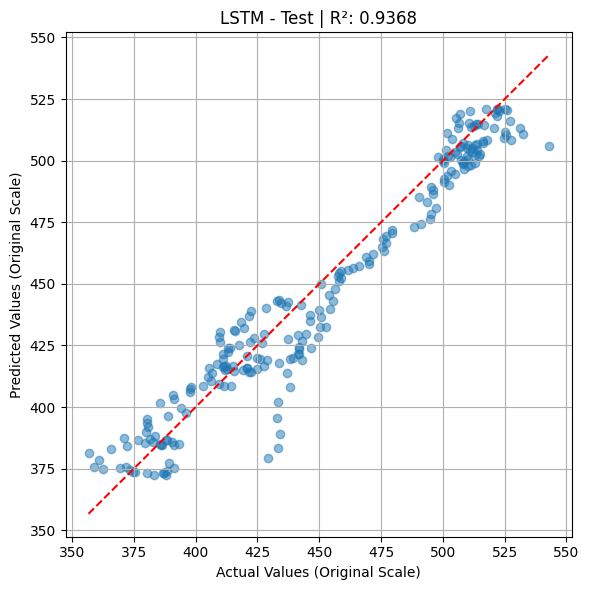

In [34]:
df_model = pandas_df.set_index('Date')
data = df_model['Mid'].values
data = data.reshape(-1,1)


training_data_len = int(len(data) * 0.80)
train_data = data[:training_data_len]
test_data = data[training_data_len:]

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)


def create_dataset(dataset, time_step=1):
    X = []
    y = []
    for i in range(len(dataset) - time_step):
        a = dataset[i:(i + time_step), 0]  # input sequence
        X.append(a)
        y.append(dataset[i + time_step, 0])  
    return np.array(X), np.array(y)

time_step = 60
X_train, y_train = create_dataset(scaled_train,time_step)
X_test, y_test = create_dataset(scaled_test,time_step)


adam_optimizer = Adam(learning_rate=0.001)

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer=adam_optimizer, loss='mean_squared_error')
model.summary()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=15,      
    batch_size=32,   
    verbose=1
)

# Get predictions for training data

print("\n")

# Model Evaluation

# Predict on training and test sets
lstm_predictions_train = model.predict(X_train)
lstm_predictions_test = model.predict(X_test)

# Rescale predictions and targets
lstm_predictions_train = scaler.inverse_transform(lstm_predictions_train).flatten()
lstm_predictions_test = scaler.inverse_transform(lstm_predictions_test).flatten()

# Reshape and Inverse Transform Training Targets
Y_train_rescaled = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()

# Reshape and Inverse Transform Test Targets
Y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# --- LSTM Scores ---
print(" LSTM Train Performance")
print("Train MSE:", mean_squared_error(Y_train_rescaled, lstm_predictions_train))
print("Train MAE:", mean_absolute_error(Y_train_rescaled, lstm_predictions_train))
print("Train R² :", r2_score(Y_train_rescaled, lstm_predictions_train))

print("\nLSTM Test Performance")

print("Test  MSE:", mean_squared_error(Y_test_rescaled, lstm_predictions_test))
print("Test  MAE:", mean_absolute_error(Y_test_rescaled, lstm_predictions_test))
print("Test  R² :", r2_score(Y_test_rescaled, lstm_predictions_test))


# --- 1. Visualizing Time Series Results (Actual vs. Prediction) ---
plt.figure(figsize=(14,5))
plt.plot(Y_test_rescaled, label='Actual')
plt.plot(lstm_predictions_test, label='LSTM Prediction')
plt.title('Stock Price Prediction: LSTM')
plt.xlabel('Time')
plt.ylabel('Mid Price (Original Scale)')
plt.legend()
plt.grid(True)
plt.show()


# --- 2. Plotting Loss ---
# Use the history object from the LSTM model fit (assumed to be named lstm_history)
train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)') 
plt.legend()
plt.grid(True)
plt.show()


# --- 3. Plotting Actual vs. Predicted Scatter Plots ---

def plot_actual_vs_predicted(actual, predicted, model_name, dataset_type):
    r2 = r2_score(actual, predicted)
    plt.figure(figsize=(6, 6))
    plt.scatter(actual, predicted, alpha=0.5)
    
    # Use np.min/np.max for the ideal line to avoid PySpark conflicts
    min_val = np.min(np.concatenate([actual.flatten(), predicted.flatten()]))
    max_val = np.max(np.concatenate([actual.flatten(), predicted.flatten()]))
    
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Fit')  
    
    plt.xlabel('Actual Values (Original Scale)')
    plt.ylabel('Predicted Values (Original Scale)')
    plt.title(f'{model_name} - {dataset_type} | R²: {r2:.4f}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    
# --- LSTM Plots ---
plot_actual_vs_predicted(Y_train_rescaled, lstm_predictions_train, model_name='LSTM', dataset_type='Train')
plot_actual_vs_predicted(Y_test_rescaled, lstm_predictions_test, model_name='LSTM', dataset_type='Test')

## Stock market prediction on RNN

### Look back window - Monthly trading cycles -21 days

In [38]:
from tensorflow.keras.layers import SimpleRNN, GRU, Dense


df_model = pandas_df.set_index('Date')
data = df_model['Mid'].values
data = data.reshape(-1,1)


# Scale the 'Mid' column
from sklearn.preprocessing import MinMaxScaler
import numpy as np

df_model = pandas_df.set_index('Date')
data = df_model['Mid'].values
data = data.reshape(-1,1)


training_data_len = int(len(data) * 0.80)
train_data = data[:training_data_len]
test_data = data[training_data_len:]

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)


def create_dataset(dataset, time_step=1):
    X = []
    y = []
    for i in range(len(dataset) - time_step):
        a = dataset[i:(i + time_step), 0]  # input sequence
        X.append(a)
        y.append(dataset[i + time_step, 0])  
    return np.array(X), np.array(y)

time_step = 21
X_train, y_train = create_dataset(scaled_train,time_step)
X_test, y_test = create_dataset(scaled_test,time_step)

/home/hduser/pyspark_venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_6 (SimpleRNN)        │ (None, 21, 25)         │           675 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,976 (7.72 KB)

 Trainable params: 1,976 (7.72 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.2401 - val_loss: 0.1465
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1332 - val_loss: 0.1270
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1117 - val_loss: 0.1031
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0926 - val_loss: 0.0855
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0760 - val_loss: 0.0708
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0618 - val_loss: 0.0564
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0498 - val_loss: 0.0461
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0398 - val_loss: 0.0367
Epoch 9/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0316 - val_loss: 0.0287
Epoch 10/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0250 - val_loss: 0.0243
Epoch 11/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0196 - val_loss: 0.0202
Epoch 12/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0156 - v

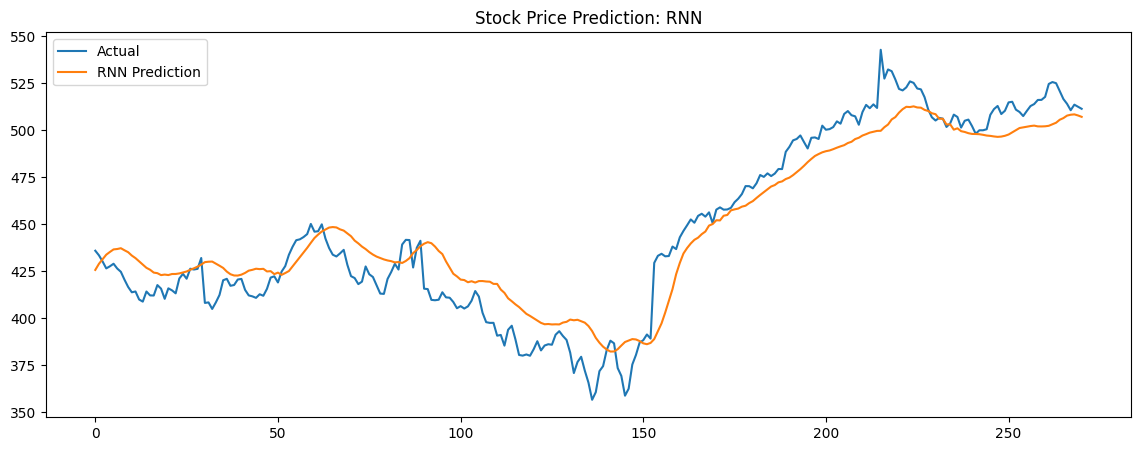

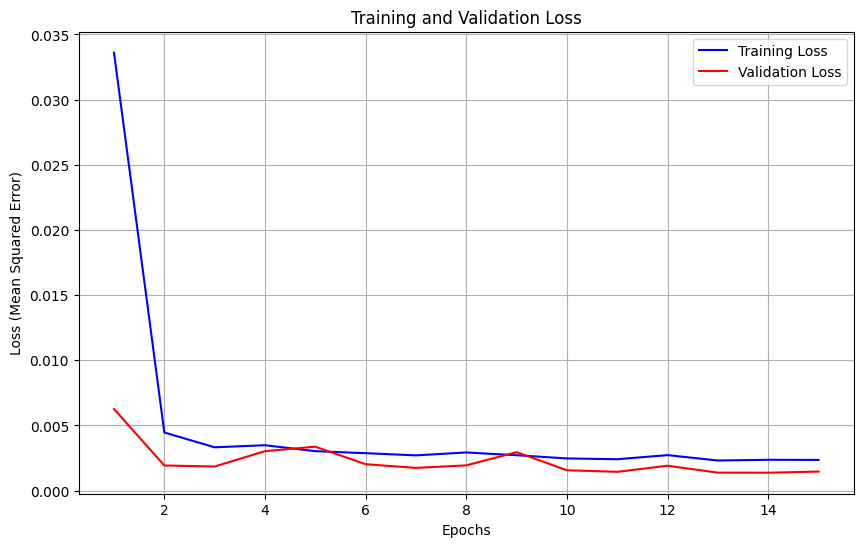

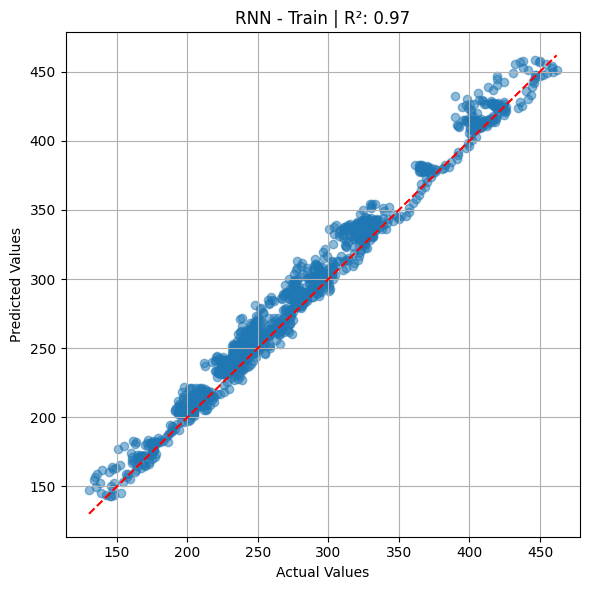

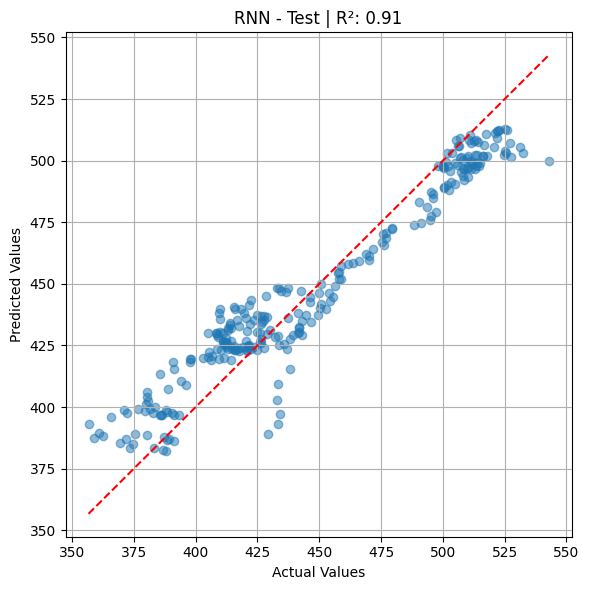

In [44]:
rnn_model = Sequential()
rnn_model.add(SimpleRNN(units=25, return_sequences=True, kernel_regularizer=l2(0.09),input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
rnn_model.add(SimpleRNN(units=25, return_sequences=False))
model.add(Dropout(0.2))
rnn_model.add(Dense(1))
rnn_model.compile(optimizer='adam', loss='mean_squared_error')
rnn_model.summary()

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    verbose=1
)


print("\n")

# Model Evaluation

# Predict on training and test sets
rnn_predictions_train = rnn_model.predict(X_train)
rnn_predictions_test = rnn_model.predict(X_test)

# Rescale predictions and targets
rnn_predictions_train = scaler.inverse_transform(rnn_predictions_train).flatten()
rnn_predictions_test = scaler.inverse_transform(rnn_predictions_test).flatten()

Y_train_rescaled = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
Y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# --- RNN Scores ---
print(" RNN Performance")
print("Train MSE:", mean_squared_error(Y_train_rescaled, rnn_predictions_train))
print("Train MAE:", mean_absolute_error(Y_train_rescaled, rnn_predictions_train))
print("Train R² :", r2_score(Y_train_rescaled, rnn_predictions_train))

print("Test  MSE:", mean_squared_error(Y_test_rescaled, rnn_predictions_test))
print("Test  MAE:", mean_absolute_error(Y_test_rescaled, rnn_predictions_test))
print("Test  R² :", r2_score(Y_test_rescaled, rnn_predictions_test))


#VIsualizing results
plt.figure(figsize=(14,5))
plt.plot(Y_test_rescaled, label='Actual')
plt.plot(rnn_predictions_test, label='RNN Prediction')
plt.title('Stock Price Prediction: RNN')
plt.legend()
plt.show()


# Plot for loss

train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)') 
plt.legend()
plt.grid(True)
plt.show()

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def plot_actual_vs_predicted(actual, predicted, model_name, dataset_type):
    r2 = r2_score(actual, predicted)
    plt.figure(figsize=(6, 6))
    plt.scatter(actual, predicted, alpha=0.5)
    plt.plot([np.min(actual), np.max(actual)], [np.min(actual), np.max(actual)], 'r--')    
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{model_name} - {dataset_type} | R²: {r2:.2f}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    
# --- RNN Plots ---
plot_actual_vs_predicted(Y_train_rescaled, rnn_predictions_train, model_name='RNN', dataset_type='Train')
plot_actual_vs_predicted(Y_test_rescaled, rnn_predictions_test, model_name='RNN', dataset_type='Test')

### Look back window - Quarterly trading cycles - 60 days

/home/hduser/pyspark_venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_12 (SimpleRNN)       │ (None, 60, 25)         │           675 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_13 (SimpleRNN)       │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,976 (7.72 KB)

 Trainable params: 1,976 (7.72 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.1619 - val_loss: 0.1132
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0054 - val_loss: 0.0292
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0027 - val_loss: 0.0198
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0019 - val_loss: 0.0150
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0015 - val_loss: 0.0110
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0013 - val_loss: 0.0091
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0011 - val_loss: 0.0081
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0010 - val_loss: 0.0060
Epoch 9/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9.1000e-04 - val_loss: 0.0050
Epoch 10/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.0533e-04 - val_loss: 0.0057
Epoch 11/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 7.5318e-04 - val_loss: 0.0056
Epoch 12/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

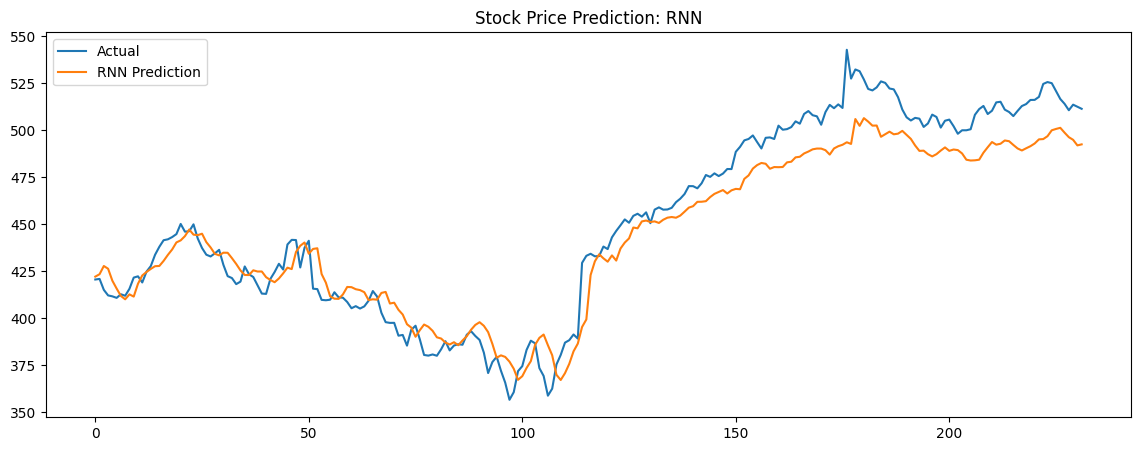

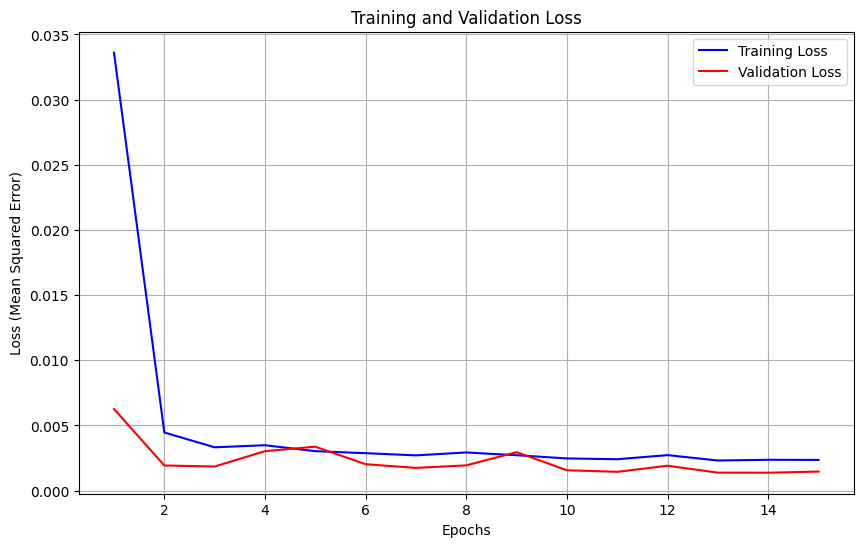

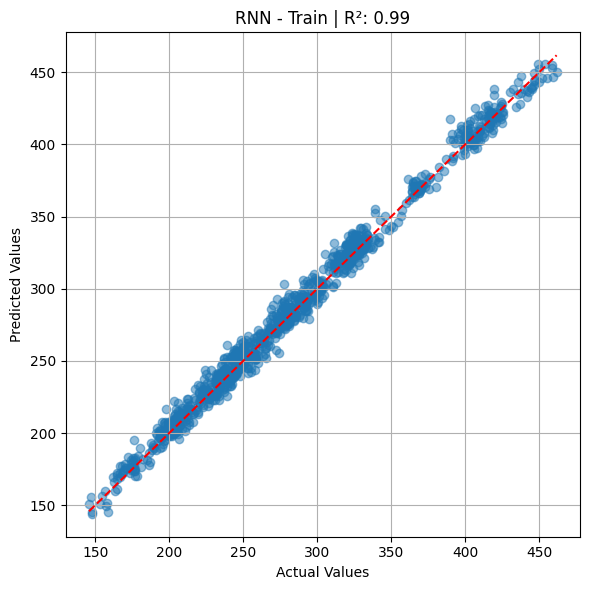

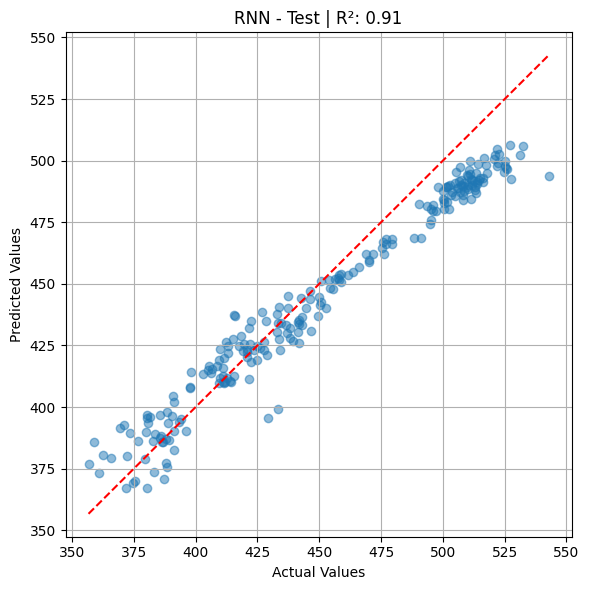

In [51]:
from tensorflow.keras.layers import SimpleRNN, GRU, Dense


df_model = pandas_df.set_index('Date')
data = df_model['Mid'].values
data = data.reshape(-1,1)


# Scale the 'Mid' column
from sklearn.preprocessing import MinMaxScaler
import numpy as np

df_model = pandas_df.set_index('Date')
data = df_model['Mid'].values
data = data.reshape(-1,1)


training_data_len = int(len(data) * 0.80)
train_data = data[:training_data_len]
test_data = data[training_data_len:]

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)


def create_dataset(dataset, time_step=1):
    X = []
    y = []
    for i in range(len(dataset) - time_step):
        a = dataset[i:(i + time_step), 0]  # input sequence
        X.append(a)
        y.append(dataset[i + time_step, 0])  
    return np.array(X), np.array(y)

time_step = 60
X_train, y_train = create_dataset(scaled_train,time_step)
X_test, y_test = create_dataset(scaled_test,time_step)

from tensorflow.keras.regularizers import l2

rnn_model = Sequential()
rnn_model.add(SimpleRNN(units=25, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.3))
rnn_model.add(SimpleRNN(units=25, return_sequences=False))
model.add(Dropout(0.3))
rnn_model.add(Dense(1))
rnn_model.compile(optimizer='adam', loss='mean_squared_error')
rnn_model.summary()

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    verbose=1
)


print("\n")

# Model Evaluation

# Predict on training and test sets
rnn_predictions_train = rnn_model.predict(X_train)
rnn_predictions_test = rnn_model.predict(X_test)

# Rescale predictions and targets
rnn_predictions_train = scaler.inverse_transform(rnn_predictions_train).flatten()
rnn_predictions_test = scaler.inverse_transform(rnn_predictions_test).flatten()

Y_train_rescaled = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
Y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# --- RNN Scores ---
print(" RNN Performance")
print("Train MSE:", mean_squared_error(Y_train_rescaled, rnn_predictions_train))
print("Train MAE:", mean_absolute_error(Y_train_rescaled, rnn_predictions_train))
print("Train R² :", r2_score(Y_train_rescaled, rnn_predictions_train))

print("Test  MSE:", mean_squared_error(Y_test_rescaled, rnn_predictions_test))
print("Test  MAE:", mean_absolute_error(Y_test_rescaled, rnn_predictions_test))
print("Test  R² :", r2_score(Y_test_rescaled, rnn_predictions_test))


#VIsualizing results
plt.figure(figsize=(14,5))
plt.plot(Y_test_rescaled, label='Actual')
plt.plot(rnn_predictions_test, label='RNN Prediction')
plt.title('Stock Price Prediction: RNN')
plt.legend()
plt.show()


# Plot for loss

train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)') 
plt.legend()
plt.grid(True)
plt.show()

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def plot_actual_vs_predicted(actual, predicted, model_name, dataset_type):
    r2 = r2_score(actual, predicted)
    plt.figure(figsize=(6, 6))
    plt.scatter(actual, predicted, alpha=0.5)
    plt.plot([np.min(actual), np.max(actual)], [np.min(actual), np.max(actual)], 'r--')    
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{model_name} - {dataset_type} | R²: {r2:.2f}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    
# --- RNN Plots ---
plot_actual_vs_predicted(Y_train_rescaled, rnn_predictions_train, model_name='RNN', dataset_type='Train')
plot_actual_vs_predicted(Y_test_rescaled, rnn_predictions_test, model_name='RNN', dataset_type='Test')


## Stock market prediction on GRU

### Look back window - Monthly trading cycles -21 days

/home/hduser/pyspark_venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_12 (SimpleRNN)       │ (None, 60, 25)         │           675 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_13 (SimpleRNN)       │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,930 (23.17 KB)

 Trainable params: 1,976 (7.72 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,954 (15.45 KB)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0914 - val_loss: 0.0428
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0295 - val_loss: 0.0373
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0209 - val_loss: 0.0174
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0166 - val_loss: 0.0098
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0132 - val_loss: 0.0096
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0122 - val_loss: 0.0063
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0103 - val_loss: 0.0074
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0096 - val_loss: 0.0056
Epoch 9/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0087 - val_loss: 0.0053
Epoch 10/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0087 - val_loss: 0.0044
Epoch 11/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0079 - val_loss: 0.0057
Epoch 12/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.007

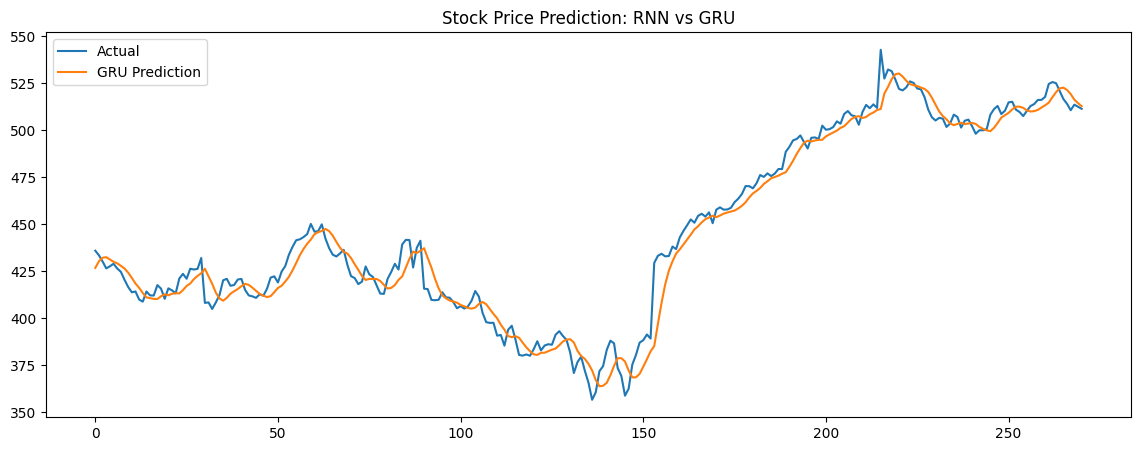

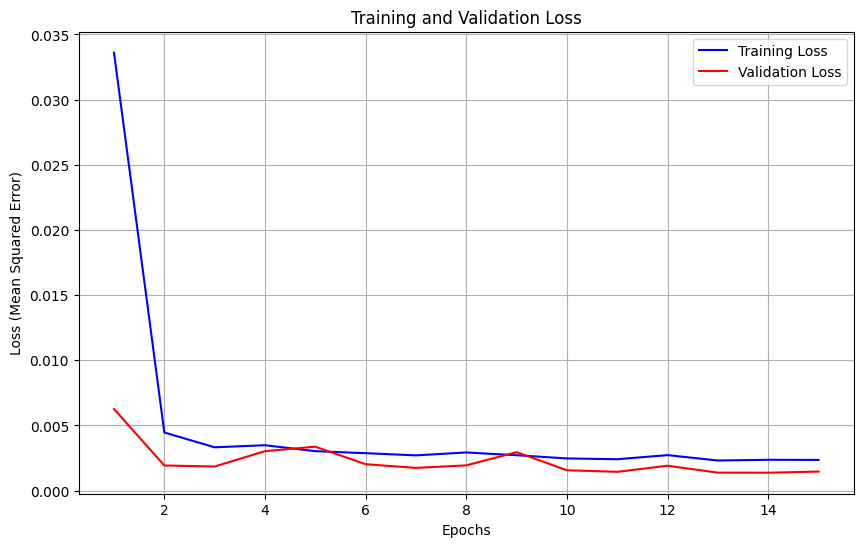

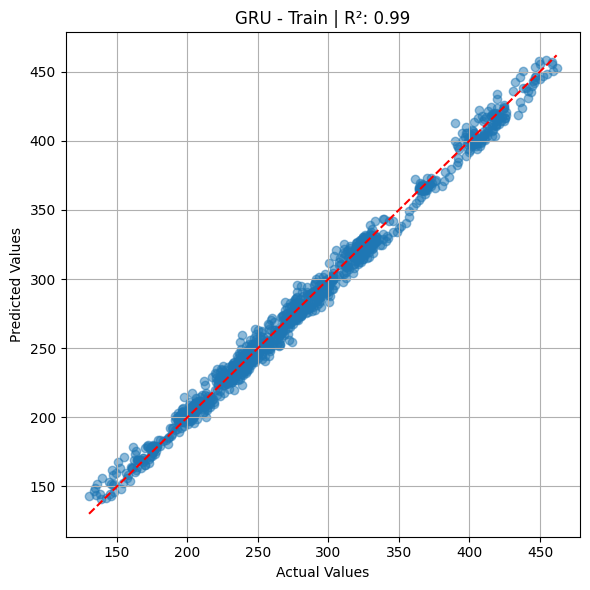

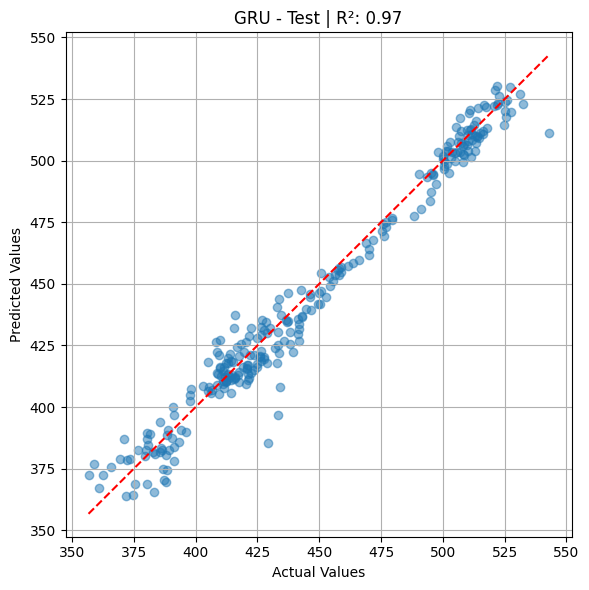

In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df_model = pandas_df.set_index('Date')
data = df_model['Mid'].values
data = data.reshape(-1,1)


# Scale the 'Mid' column
from sklearn.preprocessing import MinMaxScaler
import numpy as np

df_model = pandas_df.set_index('Date')
data = df_model['Mid'].values
data = data.reshape(-1,1)


training_data_len = int(len(data) * 0.80)
train_data = data[:training_data_len]
test_data = data[training_data_len:]

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)


def create_dataset(dataset, time_step=1):
    X = []
    y = []
    for i in range(len(dataset) - time_step):
        a = dataset[i:(i + time_step), 0]  # input sequence
        X.append(a)
        y.append(dataset[i + time_step, 0])  
    return np.array(X), np.array(y)

time_step = 21
X_train, y_train = create_dataset(scaled_train,time_step)
X_test, y_test = create_dataset(scaled_test,time_step)

gru_model = Sequential()
gru_model.add(GRU(units=30, kernel_regularizer=l2(0.01), return_sequences=False, input_shape=(X_train.shape[1], 1)))
gru_model.add(Dropout(0.3))

gru_model.add(Dense(1))

gru_model.compile(optimizer='adam', loss='mean_squared_error')
gru_model.summary()

gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    verbose=1
)


gru_predictions_train = gru_model.predict(X_train)
gru_predictions_test = gru_model.predict(X_test)


gru_predictions_train = scaler.inverse_transform(gru_predictions_train).flatten()
gru_predictions_test = scaler.inverse_transform(gru_predictions_test).flatten()

Y_train_rescaled = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
Y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()


print("\n")

# --- GRU Scores ---
print(" GRU Performance")
print("Train MSE:", mean_squared_error(Y_train_rescaled, gru_predictions_train))
print("Train MAE:", mean_absolute_error(Y_train_rescaled, gru_predictions_train))
print("Train R² :", r2_score(Y_train_rescaled, gru_predictions_train))

print("Test  MSE:", mean_squared_error(Y_test_rescaled, gru_predictions_test))
print("Test  MAE:", mean_absolute_error(Y_test_rescaled, gru_predictions_test))
print("Test  R² :", r2_score(Y_test_rescaled, gru_predictions_test))


plt.figure(figsize=(14,5))
plt.plot(Y_test_rescaled, label='Actual')
plt.plot(gru_predictions_test, label='GRU Prediction')
plt.title('Stock Price Prediction: RNN vs GRU')
plt.legend()
plt.show()

# Plot for loss

train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)') 
plt.legend()
plt.grid(True)
plt.show()

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def plot_actual_vs_predicted(actual, predicted, model_name, dataset_type):
    r2 = r2_score(actual, predicted)
    plt.figure(figsize=(6, 6))
    plt.scatter(actual, predicted, alpha=0.5)
    plt.plot([np.min(actual), np.max(actual)], [np.min(actual), np.max(actual)], 'r--')    
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{model_name} - {dataset_type} | R²: {r2:.2f}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- GRU Plots ---
plot_actual_vs_predicted(Y_train_rescaled, gru_predictions_train, model_name='GRU', dataset_type='Train')
plot_actual_vs_predicted(Y_test_rescaled, gru_predictions_test, model_name='GRU', dataset_type='Test')

### Look back window - Quarterly trading cycles - 60 days

/home/hduser/pyspark_venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_12 (SimpleRNN)       │ (None, 60, 25)         │           675 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_13 (SimpleRNN)       │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,930 (23.17 KB)

 Trainable params: 1,976 (7.72 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,954 (15.45 KB)

Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.1104 - val_loss: 0.0480
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0335 - val_loss: 0.0538
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0241 - val_loss: 0.0320
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0187 - val_loss: 0.0127
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0141 - val_loss: 0.0102
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0125 - val_loss: 0.0081
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0109 - val_loss: 0.0068
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0099 - val_loss: 0.0062
Epoch 9/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0090 - val_loss: 0.0054
Epoch 10/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0086 - val_loss: 0.0044
Epoch 11/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0085 - val_loss: 0.0040
Epoch 12/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0

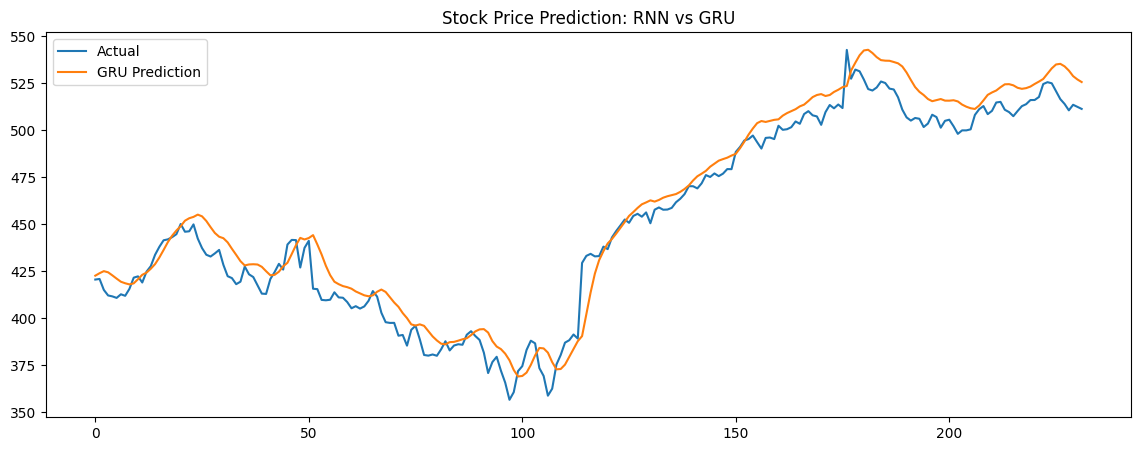

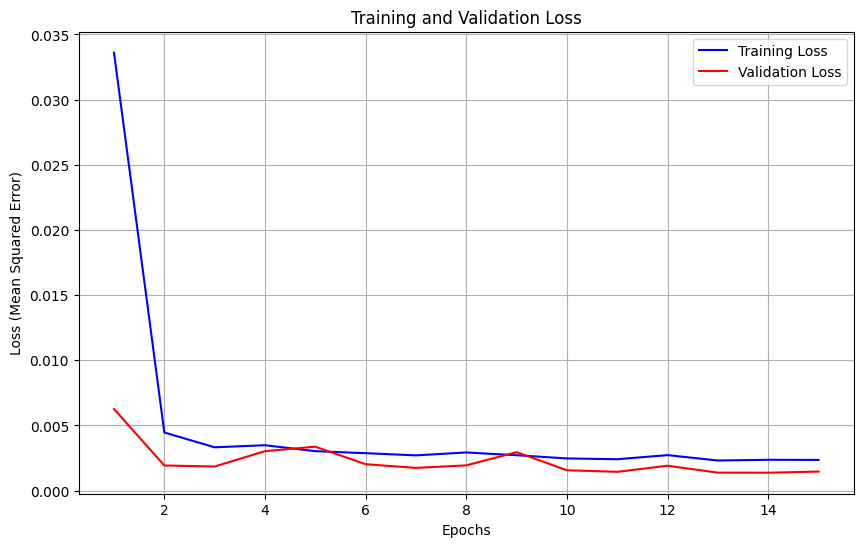

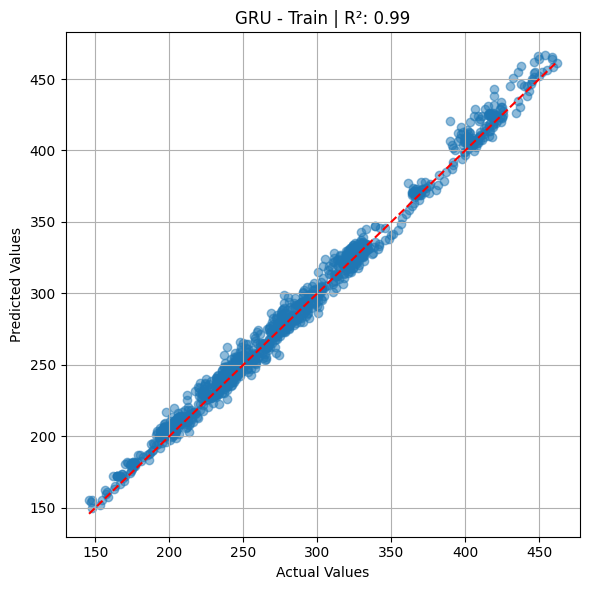

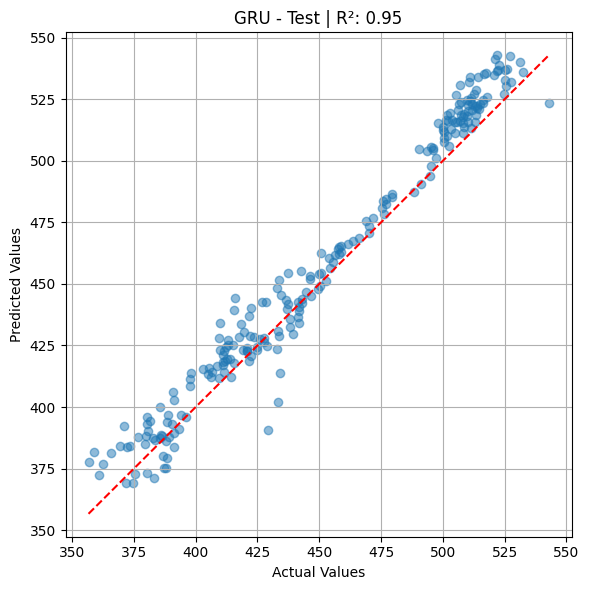

In [53]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df_model = pandas_df.set_index('Date')
data = df_model['Mid'].values
data = data.reshape(-1,1)


# Scale the 'Mid' column
from sklearn.preprocessing import MinMaxScaler
import numpy as np

df_model = pandas_df.set_index('Date')
data = df_model['Mid'].values
data = data.reshape(-1,1)


training_data_len = int(len(data) * 0.80)
train_data = data[:training_data_len]
test_data = data[training_data_len:]

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)


def create_dataset(dataset, time_step=1):
    X = []
    y = []
    for i in range(len(dataset) - time_step):
        a = dataset[i:(i + time_step), 0]  # input sequence
        X.append(a)
        y.append(dataset[i + time_step, 0])  
    return np.array(X), np.array(y)

time_step = 60
X_train, y_train = create_dataset(scaled_train,time_step)
X_test, y_test = create_dataset(scaled_test,time_step)

gru_model = Sequential()
gru_model.add(GRU(units=30, kernel_regularizer=l2(0.01), return_sequences=False, input_shape=(X_train.shape[1], 1)))
gru_model.add(Dropout(0.3))

gru_model.add(Dense(1))

gru_model.compile(optimizer='adam', loss='mean_squared_error')
gru_model.summary()

gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    verbose=1
)


gru_predictions_train = gru_model.predict(X_train)
gru_predictions_test = gru_model.predict(X_test)


gru_predictions_train = scaler.inverse_transform(gru_predictions_train).flatten()
gru_predictions_test = scaler.inverse_transform(gru_predictions_test).flatten()

Y_train_rescaled = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
Y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()


print("\n")

# --- GRU Scores ---
print(" GRU Performance")
print("Train MSE:", mean_squared_error(Y_train_rescaled, gru_predictions_train))
print("Train MAE:", mean_absolute_error(Y_train_rescaled, gru_predictions_train))
print("Train R² :", r2_score(Y_train_rescaled, gru_predictions_train))

print("Test  MSE:", mean_squared_error(Y_test_rescaled, gru_predictions_test))
print("Test  MAE:", mean_absolute_error(Y_test_rescaled, gru_predictions_test))
print("Test  R² :", r2_score(Y_test_rescaled, gru_predictions_test))


plt.figure(figsize=(14,5))
plt.plot(Y_test_rescaled, label='Actual')
plt.plot(gru_predictions_test, label='GRU Prediction')
plt.title('Stock Price Prediction: RNN vs GRU')
plt.legend()
plt.show()

# Plot for loss

train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)') 
plt.legend()
plt.grid(True)
plt.show()

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def plot_actual_vs_predicted(actual, predicted, model_name, dataset_type):
    r2 = r2_score(actual, predicted)
    plt.figure(figsize=(6, 6))
    plt.scatter(actual, predicted, alpha=0.5)
    plt.plot([np.min(actual), np.max(actual)], [np.min(actual), np.max(actual)], 'r--')    
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{model_name} - {dataset_type} | R²: {r2:.2f}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- GRU Plots ---
plot_actual_vs_predicted(Y_train_rescaled, gru_predictions_train, model_name='GRU', dataset_type='Train')
plot_actual_vs_predicted(Y_test_rescaled, gru_predictions_test, model_name='GRU', dataset_type='Test')